# Customer Churn Analytics: Predict → Value → Test → Monitor
### Business Data Analytics · Credit Card Customers · Reproducible academic notebook

**Decision principle: “Act only when expected incremental value is positive and validated.”**

**Scope statement.** This dataset represents a historical customer snapshot. Because the label horizon and feature cut-off dates are unspecified, the analysis evaluates associations and out-of-sample classification within the available snapshot, but cannot establish true future-period predictive stability.

**Executive agenda**
1. Business Understanding
2. Data Architecture and Integrity
3. Exploratory Data Analysis
4. Leakage Audit
5. Feature Engineering
6. Preprocessing Architecture
7. Baseline Models
8. Imbalanced Classification
9. Hyperparameter Optimization
10. Validation Threshold / Decision Costs
11. Final Test Evaluation
12. Probability Calibration
13. SHAP Explainability
14. Business Retention Strategy
15. Causal / Uplift Limitations and Experiment Design
16. Monitoring and Deployment Considerations
17. Final Executive Summary

| Course stage | Decision question | Deliverable |
|---|---|---|
| Business | What is churn worth? | Economic framework; no invented CLV |
| EDA | What does the data say? | Training-only behavioral associations |
| Features | How does behavior change? | Two transparent snapshot ratios |
| Models | Who is at risk? | Baselines and primary Random Forest |
| Advanced ML | How do we improve robustness? | Fold-safe tuning, uncertainty, calibration, SHAP |
| Causal Action | What should we do? | Randomized retention pilot and monitoring |

```text
Raw customer snapshot
        ↓
Data integrity audit
        ↓
Training-only EDA
        ↓
Leakage-safe feature engineering
        ↓
Train / Validation / Test
        ↓
Fold-specific preprocessing
        ↓
Model tuning on Train only
        ↓
Threshold selection on Validation only
        ↓
Frozen evaluation on Test once
        ↓
Calibration + SHAP
        ↓
Retention experiment proposal
        ↓
Monitoring
```
This conceptual diagram groups analytical stages. **Execution assigns Train/Validation/Test immediately after integrity checks, before EDA and feature inspection.** No fitted preprocessing occurs before splitting.

**Kaggle setup:** Add [Credit Card Customers](https://www.kaggle.com/datasets/sakshigoyal7/credit-card-customers/data), slug `sakshigoyal7/credit-card-customers`, through **Add Input**, then **Run All**. CPU is sufficient. CSV discovery is recursive under `/kaggle/input/`; outputs go to `/kaggle/working/`. No credentials or network downloads are required by this notebook. Optional boosting libraries are used only when installed. SHAP is required for the explanation deliverables and checked early.

**Reading convention:** Every analytical block poses a question, defines a method, displays computed results, interprets them, and states the business implication and limitation. All empirical narrative is generated from the current run; historical course numbers are comparison references only.

**Delivered execution provenance:** Embedded results were computed from the downloaded Kaggle source in a local CPU validation run using relative `kaggle/input/` and `kaggle/working/` directory mirrors. The saved code uses Kaggle’s absolute `/kaggle/input/` and `/kaggle/working/` paths. Package versions and source checksum are printed below. Run All on Kaggle refreshes the outputs; installed optional benchmarks and library versions may change fitted results.

## 1. Business understanding — What is churn worth?
**Question.** Which retention decision would create incremental customer value?

**Method / conceptual result.** Contract churn is the termination/nonrenewal of a contractual relationship. Behavioral churn is sustained disengagement under a defined activity rule. `Attrition_Flag` records source-defined attrition; the exact event rule and horizon are not documented in the table.

A production design needs an observation window $[t_0-W,t_0)$, decision point $t_0$, and label window $(t_0,t_0+H]$, satisfying $\max(\mathrm{feature\_time})<t_0<\mathrm{label\_time}$. This source cannot reconstruct that design.

| Measure | Definition | Identified here? |
|---|---|---|
| Logo churn | Lost customers / customers at period start | Only snapshot attrition prevalence; a period-start denominator is absent |
| Revenue churn | Lost recurring revenue / starting recurring revenue | No recurring-revenue history |
| Cohort retention | Surviving original cohort / starting cohort | No dated cohort trajectories |

Customer-base growth can coexist with churn when acquisitions exceed losses. Growth alone can hide an expensive retention problem.

An illustrative economic framework is
$$\mathrm{Expected\ net\ value}=P(\mathrm{churn})\times P(\mathrm{save}\mid\mathrm{action})\times CLV-\mathrm{action\ cost}.$$
Here, “save” must mean an **incremental rescue attributable to treatment**, not the observed stay rate among contacted customers. CLV should be discounted contribution margin, not gross revenue. Neither validated CLV nor intervention success is present, so no customer-level CLV or empirical ROI is calculated. A causal formulation would use $\mathrm{uplift}(x)\times\mathrm{retained\ value}(x)-\mathrm{cost}(x)$.

| Risk × CLV framework (conceptual only) | Action hypothesis |
|---|---|
| High risk, high CLV | Priority agent / tailored intervention |
| High risk, low CLV | Low-cost intervention |
| Low risk, high CLV | Protect experience; avoid unnecessary contact |
| Low risk, low CLV | Monitor |

**Interpretation.** Detecting attrition and preventing attrition are different questions.
**Business implication.** Use a classifier to propose an eligible review cohort, then test interventions.
**Limitation.** The matrix is a business framework, not an estimated CLV segmentation of these customers.

In [1]:
from pathlib import Path
import hashlib
import inspect
import json
import platform
import warnings
import importlib.metadata as metadata

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter
from IPython.display import display, Markdown
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    average_precision_score, roc_auc_score, accuracy_score, balanced_accuracy_score,
    precision_score, recall_score, f1_score, brier_score_loss, confusion_matrix,
    PrecisionRecallDisplay, RocCurveDisplay, ConfusionMatrixDisplay,
)
from sklearn.calibration import calibration_curve

try:
    import shap
except ImportError as exc:
    raise ImportError("SHAP is required for section 13. Use a Kaggle Python image with shap installed.") from exc

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
INPUT_ROOT = Path("kaggle/input")
OUTPUT_DIR = Path("kaggle/working")
FIGURE_DIR = OUTPUT_DIR / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
N_JOBS = 2  # Limit concurrent fits; each forest uses one worker inside CV.
BOOTSTRAP_REPEATS = 500
SHAP_SAMPLE_SIZE = 200
MIN_SEGMENT_N = 30
MIN_AUDIT_N = 100
MIN_AUDIT_POSITIVES = 20
FN_COST, FP_COST = 5, 1
ASSOCIATION_NOTE = (
    "Observational training-set associations only. Customer mix, confounding, label timing, "
    "and correlated behaviors may explain differences; association does not establish causation."
)
sns.set_theme(style="whitegrid", context="notebook", palette="colorblind")
plt.rcParams.update({"figure.dpi": 110, "axes.titleweight": "bold"})
pd.set_option("display.max_columns", 30)

def save_figure(name):
    fig = plt.gcf()
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / f"{name}.png", dpi=160, bbox_inches="tight")
    plt.show()
    plt.close(fig)

def report(text):
    display(Markdown(text))

versions = {"python": platform.python_version()}
for package in ["numpy", "pandas", "scikit-learn", "matplotlib", "seaborn", "shap"]:
    versions[package] = metadata.version(package)
display(pd.Series(versions, name="version").to_frame())
print("Reproducible seed:", RANDOM_STATE)

,version
python,3.13.5
numpy,2.4.2
pandas,3.0.0
scikit-learn,1.8.0
matplotlib,3.10.8
seaborn,0.13.2
shap,0.52.0


Reproducible seed: 42


## 2. Data architecture and integrity — Is one row one customer snapshot?
**Question.** Is the attached file the expected source, and is its customer key valid?
**Method.** Inspect headers recursively, choose the sole target-bearing file (prefer the named dataset directory if needed), validate schema/categories, then audit all records for integrity. Ambiguous sources fail closed.
**Result.** The next cells print the selected path, checksum, dimensions, dictionary and audit tables.
**Interpretation / business implication.** Identity and schema checks protect evaluation from repeated customers or unintended target fields.
**Limitation.** A clean table does not establish temporal eligibility, representative sampling, or causal identification. Full-source inspection here describes architecture only.

In [2]:
csv_paths = sorted(p for p in INPUT_ROOT.rglob("*") if p.is_file() and p.suffix.lower() == ".csv")
candidates, unreadable = [], []
for path in csv_paths:
    try:
        header = pd.read_csv(path, nrows=0)
    except (OSError, UnicodeError, pd.errors.ParserError, pd.errors.EmptyDataError) as exc:
        unreadable.append((str(path), type(exc).__name__))
        continue
    if "Attrition_Flag" in header.columns:
        candidates.append(path)
print(f"CSV files inspected: {len(csv_paths)}; target-bearing candidates: {len(candidates)}")
if unreadable:
    print("Unreadable CSV headers:", unreadable)
if not candidates:
    raise FileNotFoundError("No CSV containing Attrition_Flag found under /kaggle/input/. Add sakshigoyal7/credit-card-customers as Input.")
preferred = [p for p in candidates if "credit-card-customers" in str(p).lower()]
pool = preferred if preferred else candidates
if len(pool) != 1:
    raise ValueError(f"Ambiguous target-bearing input files; attach one source version: {pool}")
input_file = pool[0]
print("Selected input file:", input_file)
source_sha256 = hashlib.sha256(input_file.read_bytes()).hexdigest()
print("Source SHA-256:", source_sha256)
raw = pd.read_csv(input_file)
assert raw.columns.is_unique, "Duplicate column names require source correction."
assert "Churn" not in raw.columns, "Unexpected precomputed Churn column: inspect source before proceeding."
assert "CLIENTNUM" in raw.columns, "Customer key CLIENTNUM is required for group checks."
assert raw["Attrition_Flag"].notna().all(), "Missing target labels require source review."
expected_labels = {"Attrited Customer", "Existing Customer"}
assert set(raw["Attrition_Flag"].unique()) == expected_labels, "Unexpected target categories or a missing class."
print("Source dimensions:", raw.shape)
print("Columns:", raw.columns.tolist())
display(raw.head())
display(raw.dtypes.astype(str).rename("dtype").to_frame())
display(raw.describe(include="all").T)
display(raw["Attrition_Flag"].value_counts().rename("n").to_frame())

CSV files inspected: 1; target-bearing candidates: 1
Selected input file: kaggle/input/credit-card-customers/BankChurners.csv
Source SHA-256: c91b525a2a6755a1b0b80dad1d0d008ca97ec4df34552c8f47ffa12b6184b779
Source dimensions: (10127, 23)
Columns: ['CLIENTNUM', 'Attrition_Flag', 'Customer_Age', 'Gender', 'Dependent_count', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category', 'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal', 'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio', 'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1', 'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2']


,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.99998
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.99987
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.99998


,dtype
CLIENTNUM,int64
Attrition_Flag,str
Customer_Age,int64
Gender,str
Dependent_count,int64
Education_Level,str
Marital_Status,str
Income_Category,str
Card_Category,str
Months_on_book,int64


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
CLIENTNUM,10127.0,NaN,NaN,NaN,739177606.333663,36903783.450231,708082083.0,713036770.5,717926358.0,773143533.0,828343083.0
Attrition_Flag,10127,2,Existing Customer,8500,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer_Age,10127.0,NaN,NaN,NaN,46.32596,8.016814,26.0,41.0,46.0,52.0,73.0
Gender,10127,2,F,5358,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependent_count,10127.0,NaN,NaN,NaN,2.346203,1.298908,0.0,1.0,2.0,3.0,5.0
Education_Level,10127,7,Graduate,3128,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Marital_Status,10127,4,Married,4687,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Income_Category,10127,6,Less than $40K,3561,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Card_Category,10127,4,Blue,9436,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Months_on_book,10127.0,NaN,NaN,NaN,35.928409,7.986416,13.0,31.0,36.0,40.0,56.0


,n
Attrition_Flag,
Existing Customer,8500
Attrited Customer,1627


In [3]:
# Dictionary meanings follow source field labels; currency and calendar boundaries remain unspecified.
field_info = {
    "CLIENTNUM": ("Identity / demographics", "Customer identifier", "identifier", "Snapshot key"),
    "Customer_Age": ("Identity / demographics", "Customer age", "years", "Measurement date unspecified"),
    "Gender": ("Identity / demographics", "Recorded gender category", "category", "Collection definition unspecified"),
    "Dependent_count": ("Identity / demographics", "Recorded dependents", "count", "Measurement date unspecified"),
    "Education_Level": ("Identity / demographics", "Education category", "category", "Unknown is explicit"),
    "Marital_Status": ("Identity / demographics", "Marital-status category", "category", "Unknown is explicit"),
    "Income_Category": ("Identity / demographics", "Income band as recorded", "source category", "Currency/period unspecified in table"),
    "Card_Category": ("Plan / relationship", "Card tier", "category", "Snapshot"),
    "Months_on_book": ("Plan / relationship", "Length of relationship", "months", "As-of date unspecified"),
    "Total_Relationship_Count": ("Plan / relationship", "Products/relationships held", "count", "As-of date unspecified"),
    "Months_Inactive_12_mon": ("Behavior / transactions", "Inactive months", "months", "12-month label; calendar boundaries unspecified"),
    "Contacts_Count_12_mon": ("Service / contact", "Recorded contacts", "count", "12-month label; direction/reason unspecified"),
    "Credit_Limit": ("Money / credit", "Credit limit", "currency unspecified", "As-of date unspecified"),
    "Total_Revolving_Bal": ("Money / credit", "Revolving balance", "currency unspecified", "As-of date unspecified"),
    "Avg_Open_To_Buy": ("Money / credit", "Average open-to-buy credit", "currency unspecified", "Averaging window unspecified"),
    "Total_Amt_Chng_Q4_Q1": ("Behavior / transactions", "Amount change measure Q4 versus Q1", "dimensionless source ratio", "Calendar year / exact formula unspecified"),
    "Total_Trans_Amt": ("Behavior / transactions", "Total transaction amount", "currency unspecified", "Exact cut-off and aggregation window unspecified in CSV"),
    "Total_Trans_Ct": ("Behavior / transactions", "Transaction count", "count", "Exact cut-off and aggregation window unspecified in CSV"),
    "Total_Ct_Chng_Q4_Q1": ("Behavior / transactions", "Count change measure Q4 versus Q1", "dimensionless source ratio", "Calendar year / exact formula unspecified"),
    "Avg_Utilization_Ratio": ("Money / credit", "Average utilization", "ratio", "Averaging window unspecified"),
    "Attrition_Flag": ("Target", "Source attrition category", "category", "Outcome horizon unspecified"),
}
dictionary_rows = []
for field in raw.columns:
    info = field_info.get(field, ("Unspecified", "Unspecified; requires schema review", "unspecified", "unspecified"))
    if "naive_bayes_classifier_attrition_flag" in field.lower():
        info = ("Target-related source output", "Source classifier output; exclude", "probability-like score", "Training origin unspecified")
    dictionary_rows.append([field, str(raw[field].dtype), *info])
data_dictionary = pd.DataFrame(dictionary_rows, columns=["field", "dtype", "group", "meaning", "unit", "window_or_note"])
display(data_dictionary)
data_dictionary.to_csv(OUTPUT_DIR / "data_dictionary.csv", index=False)

,field,dtype,group,meaning,unit,window_or_note
0,CLIENTNUM,int64,Identity / demographics,Customer identifier,identifier,Snapshot key
1,Attrition_Flag,str,Target,Source attrition category,category,Outcome horizon unspecified
2,Customer_Age,int64,Identity / demographics,Customer age,years,Measurement date unspecified
3,Gender,str,Identity / demographics,Recorded gender category,category,Collection definition unspecified
4,Dependent_count,int64,Identity / demographics,Recorded dependents,count,Measurement date unspecified
5,Education_Level,str,Identity / demographics,Education category,category,Unknown is explicit
6,Marital_Status,str,Identity / demographics,Marital-status category,category,Unknown is explicit
7,Income_Category,str,Identity / demographics,Income band as recorded,source category,Currency/period unspecified in table
8,Card_Category,str,Plan / relationship,Card tier,category,Snapshot
9,Months_on_book,int64,Plan / relationship,Length of relationship,months,As-of date unspecified


In [4]:
numeric_raw = raw.select_dtypes(include=np.number)
quality = pd.DataFrame({
    "missing_cells": raw.isna().sum(),
    "unique_nonmissing": raw.nunique(dropna=True),
    "unknown_category_cells": raw.apply(lambda s: s.astype("string").eq("Unknown").sum()),
})
quality["infinite_cells"] = 0
quality.loc[numeric_raw.columns, "infinite_cells"] = np.isinf(numeric_raw).sum().astype(int)
display(quality)
print("Unique customers:", raw["CLIENTNUM"].nunique())
print("Exact duplicated rows:", int(raw.duplicated().sum()))
print("Duplicate CLIENTNUM values beyond first:", int(raw["CLIENTNUM"].duplicated().sum()))
for field in raw.select_dtypes(exclude=np.number).columns:
    print(field, ":", sorted(raw[field].dropna().astype(str).unique().tolist()))

nonnegative_fields = [f for f in field_info if f in numeric_raw and f != "CLIENTNUM"]
range_rows = []
for field in nonnegative_fields:
    values = raw[field].dropna()
    invalid = values.lt(0)
    if field == "Months_Inactive_12_mon":
        invalid |= values.gt(12)
    if field == "Avg_Utilization_Ratio":
        invalid |= values.gt(1)
    if field == "Customer_Age":
        invalid |= values.le(0)
    range_rows.append({"field": field, "min": values.min(), "max": values.max(), "invalid_n": int(invalid.sum())})
range_audit = pd.DataFrame(range_rows)
display(range_audit)
assert quality["infinite_cells"].sum() == 0, "Infinite source values require explicit correction."
assert range_audit["invalid_n"].sum() == 0, "Invalid ranges require source review; no silent clipping."
assert raw["CLIENTNUM"].notna().all(), "Missing customer keys require source review."

exact_duplicates = int(raw.duplicated().sum())
if exact_duplicates:
    report(f"**Integrity decision:** Remove {exact_duplicates} repeated copies of entire rows, including the same customer key and target. Keep one source record per exact duplicate. Distinct customer keys are never deduplicated by matching feature profiles.")
    data = raw.drop_duplicates().copy()
else:
    data = raw.copy()
    report("**Integrity result:** No exact duplicate rows removed.")
assert data["CLIENTNUM"].is_unique, "Conflicting snapshots share CLIENTNUM; resolve customer history before random splitting."
data["Churn"] = data["Attrition_Flag"].map({"Attrited Customer": 1, "Existing Customer": 0}).astype(int)
assert set(data["Churn"].unique()) == {0, 1}
report(f"**Result:** {int(raw.isna().sum().sum()):,} conventional missing cells; {int(quality['unknown_category_cells'].sum()):,} explicit Unknown entries. Unknown categories are retained. No different customers are removed for identical predictor profiles.")

,missing_cells,unique_nonmissing,unknown_category_cells,infinite_cells
CLIENTNUM,0,10127,0,0
Attrition_Flag,0,2,0,0
Customer_Age,0,45,0,0
Gender,0,2,0,0
Dependent_count,0,6,0,0
Education_Level,0,7,1519,0
Marital_Status,0,4,749,0
Income_Category,0,6,1112,0
Card_Category,0,4,0,0
Months_on_book,0,44,0,0


Unique customers: 10127
Exact duplicated rows: 0
Duplicate CLIENTNUM values beyond first: 0
Attrition_Flag : ['Attrited Customer', 'Existing Customer']
Gender : ['F', 'M']
Education_Level : ['College', 'Doctorate', 'Graduate', 'High School', 'Post-Graduate', 'Uneducated', 'Unknown']
Marital_Status : ['Divorced', 'Married', 'Single', 'Unknown']
Income_Category : ['$120K +', '$40K - $60K', '$60K - $80K', '$80K - $120K', 'Less than $40K', 'Unknown']
Card_Category : ['Blue', 'Gold', 'Platinum', 'Silver']


,field,min,max,invalid_n
0,Customer_Age,26.0,73.000,0
1,Dependent_count,0.0,5.000,0
2,Months_on_book,13.0,56.000,0
3,Total_Relationship_Count,1.0,6.000,0
4,Months_Inactive_12_mon,0.0,6.000,0
5,Contacts_Count_12_mon,0.0,6.000,0
6,Credit_Limit,1438.3,34516.000,0
7,Total_Revolving_Bal,0.0,2517.000,0
8,Avg_Open_To_Buy,3.0,34516.000,0
9,Total_Amt_Chng_Q4_Q1,0.0,3.397,0


**Integrity result:** No exact duplicate rows removed.

**Result:** 0 conventional missing cells; 3,380 explicit Unknown entries. Unknown categories are retained. No different customers are removed for identical predictor profiles.

### Target prevalence and the majority baseline
**Question.** How misleading could accuracy be? **Method.** Count both snapshot labels and compare actual values with the historical course reference.
**Interpretation.** Predicting every customer as retained can have high accuracy but zero churn recall. **Business implication.** Rank models primarily by Average Precision.
**Limitation.** This is sample attrition prevalence, not a dated population churn rate. Population sampling and selection weights are unknown.

,n,percentage
class,,
Retained,8500,83.934038
Churned,1627,16.065962


,measure,historical_reference,actual,difference
0,Source rows,10127,10127,0
1,Source columns,23,23,0
2,Retained,8500,8500,0
3,Churned,1627,1627,0


Historical-reference differences: none


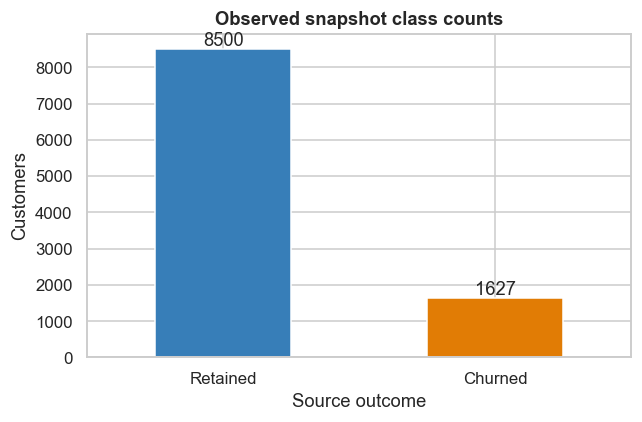

**Result:** 10,127 customers; churn share 16.07%; retained share 83.93%. Majority-class accuracy = 83.93%. Predict-all-retained churn recall = 0%; its high accuracy would not locate a single churner.

In [5]:
target_table = data["Churn"].value_counts().reindex([0, 1]).rename("n").to_frame()
target_table.index = pd.Index(["Retained", "Churned"], name="class")
target_table["percentage"] = 100 * target_table["n"] / len(data)
display(target_table)
cohort_n = len(data)
cohort_prevalence = float(data["Churn"].mean())
majority_accuracy = float(data["Churn"].value_counts(normalize=True).max())
historical_comparison = pd.DataFrame({
    "measure": ["Source rows", "Source columns", "Retained", "Churned"],
    "historical_reference": [10127, 23, 8500, 1627],
    "actual": [len(raw), raw.shape[1], int(target_table.loc["Retained", "n"]), int(target_table.loc["Churned", "n"])],
})
historical_comparison["difference"] = historical_comparison["actual"] - historical_comparison["historical_reference"]
display(historical_comparison)
print("Historical-reference differences:", "none" if historical_comparison["difference"].eq(0).all() else "present; actual values are used throughout")
ax = target_table["n"].plot.bar(color=["#377eb8", "#e17c05"], rot=0, figsize=(6, 4))
ax.set(title="Observed snapshot class counts", xlabel="Source outcome", ylabel="Customers")
for container in ax.containers:
    ax.bar_label(container, fmt="%d")
save_figure("target_counts")
report(f"**Result:** {cohort_n:,} customers; churn share {cohort_prevalence:.2%}; retained share {1-cohort_prevalence:.2%}. Majority-class accuracy = {majority_accuracy:.2%}. Predict-all-retained churn recall = 0%; its high accuracy would not locate a single churner.")

### Partition contract — fixed before training-only EDA
**Question.** Which data may influence each decision? **Method.** Reproducible stratified 60/20/20 split with disjoint customer IDs.

| Partition | Permitted use |
|---|---|
| Train | EDA, pipeline fitting, identical 3-fold CV, hyperparameter selection |
| Validation | Final model choice under a predeclared rule, then cost threshold selection |
| Test | One frozen scoring pass; reuse the same predictions for metrics, bootstrap, calibration, subgroup audit and explanation |

**Predeclared model policy.** Random Forest is the primary course model. Choose its baseline or tuned variant by training CV AP only (ties favor the simpler baseline). Compare this forest and the other model families on Validation. Retain the forest if its AP is within 0.01 of the validation AP leader and its Brier score is no more than 0.02 worse; otherwise use the validation AP leader (ties favor higher Train CV AP, then lower Brier). These practical tolerance margins are teaching choices, not significance tests. The forest's interpretability breaks a close practical comparison; a clearly stronger challenger becomes the final predictive model. If that happens, label TreeSHAP as explaining the separate course-aligned forest. No test leaderboard is created.

**Limitation.** The random holdout is pragmatic within-snapshot validation, never out-of-time validation. No refit on Train+Validation occurs after threshold choice, because that would change the probability scale underlying the frozen threshold.

In [6]:
train_idx, temporary_idx = train_test_split(data.index, train_size=0.60, stratify=data["Churn"], random_state=RANDOM_STATE)
validation_idx, test_idx = train_test_split(temporary_idx, test_size=0.50, stratify=data.loc[temporary_idx, "Churn"], random_state=RANDOM_STATE)
partitions = {"Train": train_idx, "Validation": validation_idx, "Test": test_idx}
partition_summary = pd.DataFrame([
    {"partition": name, "n": len(idx), "churn_n": int(data.loc[idx, "Churn"].sum()), "churn_prevalence": data.loc[idx, "Churn"].mean()}
    for name, idx in partitions.items()
])
display(partition_summary)
id_sets = {name: set(data.loc[idx, "CLIENTNUM"]) for name, idx in partitions.items()}
assert not (id_sets["Train"] & id_sets["Validation"])
assert not (id_sets["Train"] & id_sets["Test"])
assert not (id_sets["Validation"] & id_sets["Test"])
assert sum(map(len, id_sets.values())) == len(data)
assert all(data.loc[idx, "Churn"].nunique() == 2 for idx in partitions.values())
train = data.loc[train_idx].copy()
print("Customer IDs are unique and disjoint across all three partitions.")

,partition,n,churn_n,churn_prevalence
0,Train,6076,976,0.160632
1,Validation,2025,325,0.160494
2,Test,2026,326,0.160908


Customer IDs are unique and disjoint across all three partitions.


## 3. Training-only EDA — What does behavior say?
**Question.** Are transaction activity, inactivity and relationship depth associated with observed attrition?
**Method.** Use training-only quantile groups and observed discrete values. Report n, churn count, rate, Wilson 95% binomial intervals and small-group flags. Wilson intervals quantify sampling uncertainty within a group; they do not adjust for confounding or multiple comparisons.
**Result / interpretation.** The following tables and captions use computed values. **Business implication.** Patterns propose engagement/service hypotheses for later experiments.
**Limitation.** Every segment comparison is observational. An extreme rate from a tiny group is not a defensible production rule.

,n,churn_count,churn_rate,ci_low,ci_high,small_n
Transaction_quartile,,,,,,
"(9.999, 45.0]",1585,594,0.374763,0.351262,0.398870,False
"(45.0, 67.0]",1485,297,0.200000,0.180441,0.221107,False
"(67.0, 81.0]",1608,67,0.041667,0.032943,0.052575,False
"(81.0, 139.0]",1398,18,0.012876,0.008160,0.020261,False


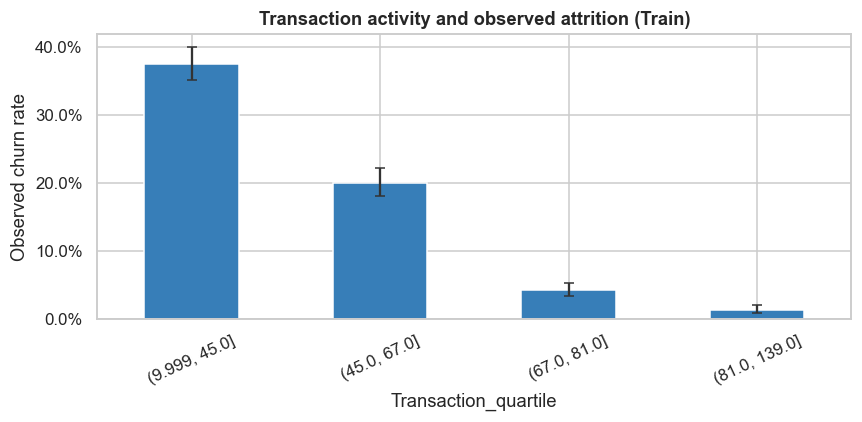

Observational training-set associations only. Customer mix, confounding, label timing, and correlated behaviors may explain differences; association does not establish causation. Groups with n < 30 are flagged; intervals are unadjusted Wilson 95% intervals.

,n,churn_count,churn_rate,ci_low,ci_high,small_n
Months_Inactive_12_mon,,,,,,
0,14,8,0.571429,0.325903,0.786195,True
1,1332,57,0.042793,0.033175,0.055040,False
2,1994,317,0.158977,0.143585,0.175680,False
3,2308,496,0.214905,0.198628,0.232129,False
4,252,73,0.289683,0.237166,0.348515,False
5,106,14,0.132075,0.080331,0.209555,False
6,70,11,0.157143,0.090075,0.259885,False


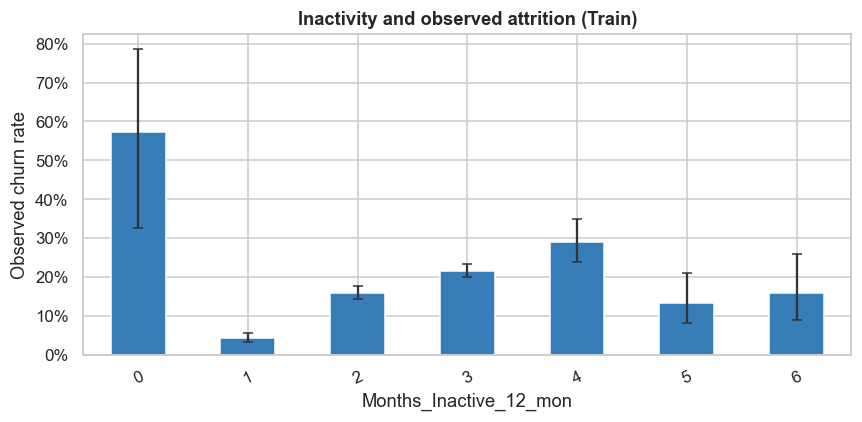

Observational training-set associations only. Customer mix, confounding, label timing, and correlated behaviors may explain differences; association does not establish causation. Groups with n < 30 are flagged; intervals are unadjusted Wilson 95% intervals.

,n,churn_count,churn_rate,ci_low,ci_high,small_n
Total_Relationship_Count,,,,,,
1,527,136,0.258065,0.222550,0.297080,False
2,732,213,0.290984,0.259238,0.324912,False
3,1430,241,0.168531,0.150023,0.188816,False
4,1135,136,0.119824,0.102201,0.140011,False
5,1140,126,0.110526,0.093617,0.130052,False
6,1112,124,0.111511,0.094331,0.131365,False


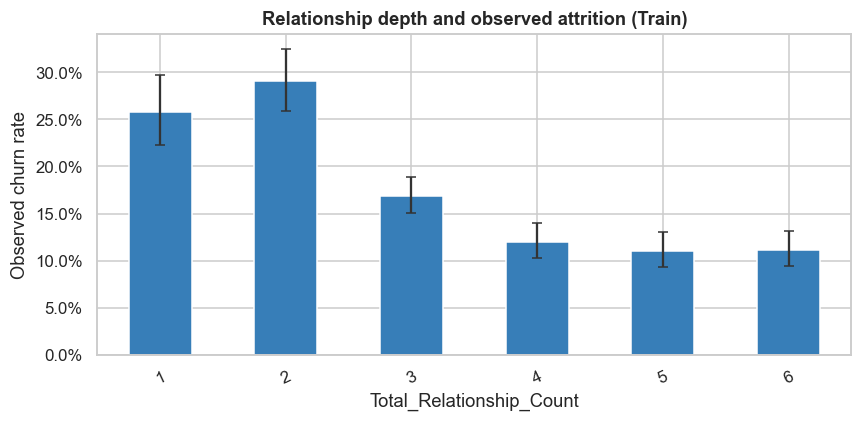

Observational training-set associations only. Customer mix, confounding, label timing, and correlated behaviors may explain differences; association does not establish causation. Groups with n < 30 are flagged; intervals are unadjusted Wilson 95% intervals.

**Result:** Lowest transaction-count band churn = 37.5%; highest band = 1.3%; difference = +36.2 percentage points. **Interpretation:** Lower activity is associated with higher attrition in these bands. **Business implication:** Treat engagement review as a candidate hypothesis, not a validated rescue rule.

In [7]:
def segment_summary(frame, group):
    result = frame.groupby(group, observed=True, dropna=False)["Churn"].agg(n="size", churn_count="sum", churn_rate="mean")
    n, rate, z = result["n"], result["churn_rate"], 1.96
    center = (rate + z*z/(2*n)) / (1 + z*z/n)
    half = z * np.sqrt(rate*(1-rate)/n + z*z/(4*n*n)) / (1 + z*z/n)
    result["ci_low"], result["ci_high"] = center-half, center+half
    result["small_n"] = n < MIN_SEGMENT_N
    return result

def show_segment(table, title, name):
    display(table)
    ax = table["churn_rate"].plot.bar(figsize=(8, 4), rot=25, color="#377eb8")
    ax.errorbar(np.arange(len(table)), table["churn_rate"],
                yerr=np.vstack([table["churn_rate"]-table["ci_low"], table["ci_high"]-table["churn_rate"]]),
                fmt="none", ecolor="#333333", capsize=3)
    ax.set(title=title + " (Train)", xlabel=table.index.name, ylabel="Observed churn rate")
    ax.yaxis.set_major_formatter(PercentFormatter(1))
    save_figure(name)
    report(ASSOCIATION_NOTE + f" Groups with n < {MIN_SEGMENT_N} are flagged; intervals are unadjusted Wilson 95% intervals.")

train["Transaction_quartile"] = pd.qcut(train["Total_Trans_Ct"], q=4, duplicates="drop")
transaction_segments = segment_summary(train, "Transaction_quartile")
assert len(transaction_segments) >= 2, "Insufficient transaction variation for quantile EDA."
inactivity_segments = segment_summary(train, "Months_Inactive_12_mon")
relationship_segments = segment_summary(train, "Total_Relationship_Count")
show_segment(transaction_segments, "Transaction activity and observed attrition", "eda_transaction_quartiles")
show_segment(inactivity_segments, "Inactivity and observed attrition", "eda_inactivity")
show_segment(relationship_segments, "Relationship depth and observed attrition", "eda_relationship_depth")
low_activity_rate = float(transaction_segments.iloc[0]["churn_rate"])
high_activity_rate = float(transaction_segments.iloc[-1]["churn_rate"])
report(f"**Result:** Lowest transaction-count band churn = {low_activity_rate:.1%}; highest band = {high_activity_rate:.1%}; difference = {100*(low_activity_rate-high_activity_rate):+.1f} percentage points. **Interpretation:** {'Lower activity is associated with higher attrition in these bands.' if low_activity_rate > high_activity_rate else 'These bands do not support the expected lower-activity/higher-attrition direction.'} **Business implication:** Treat engagement review as a candidate hypothesis, not a validated rescue rule.")

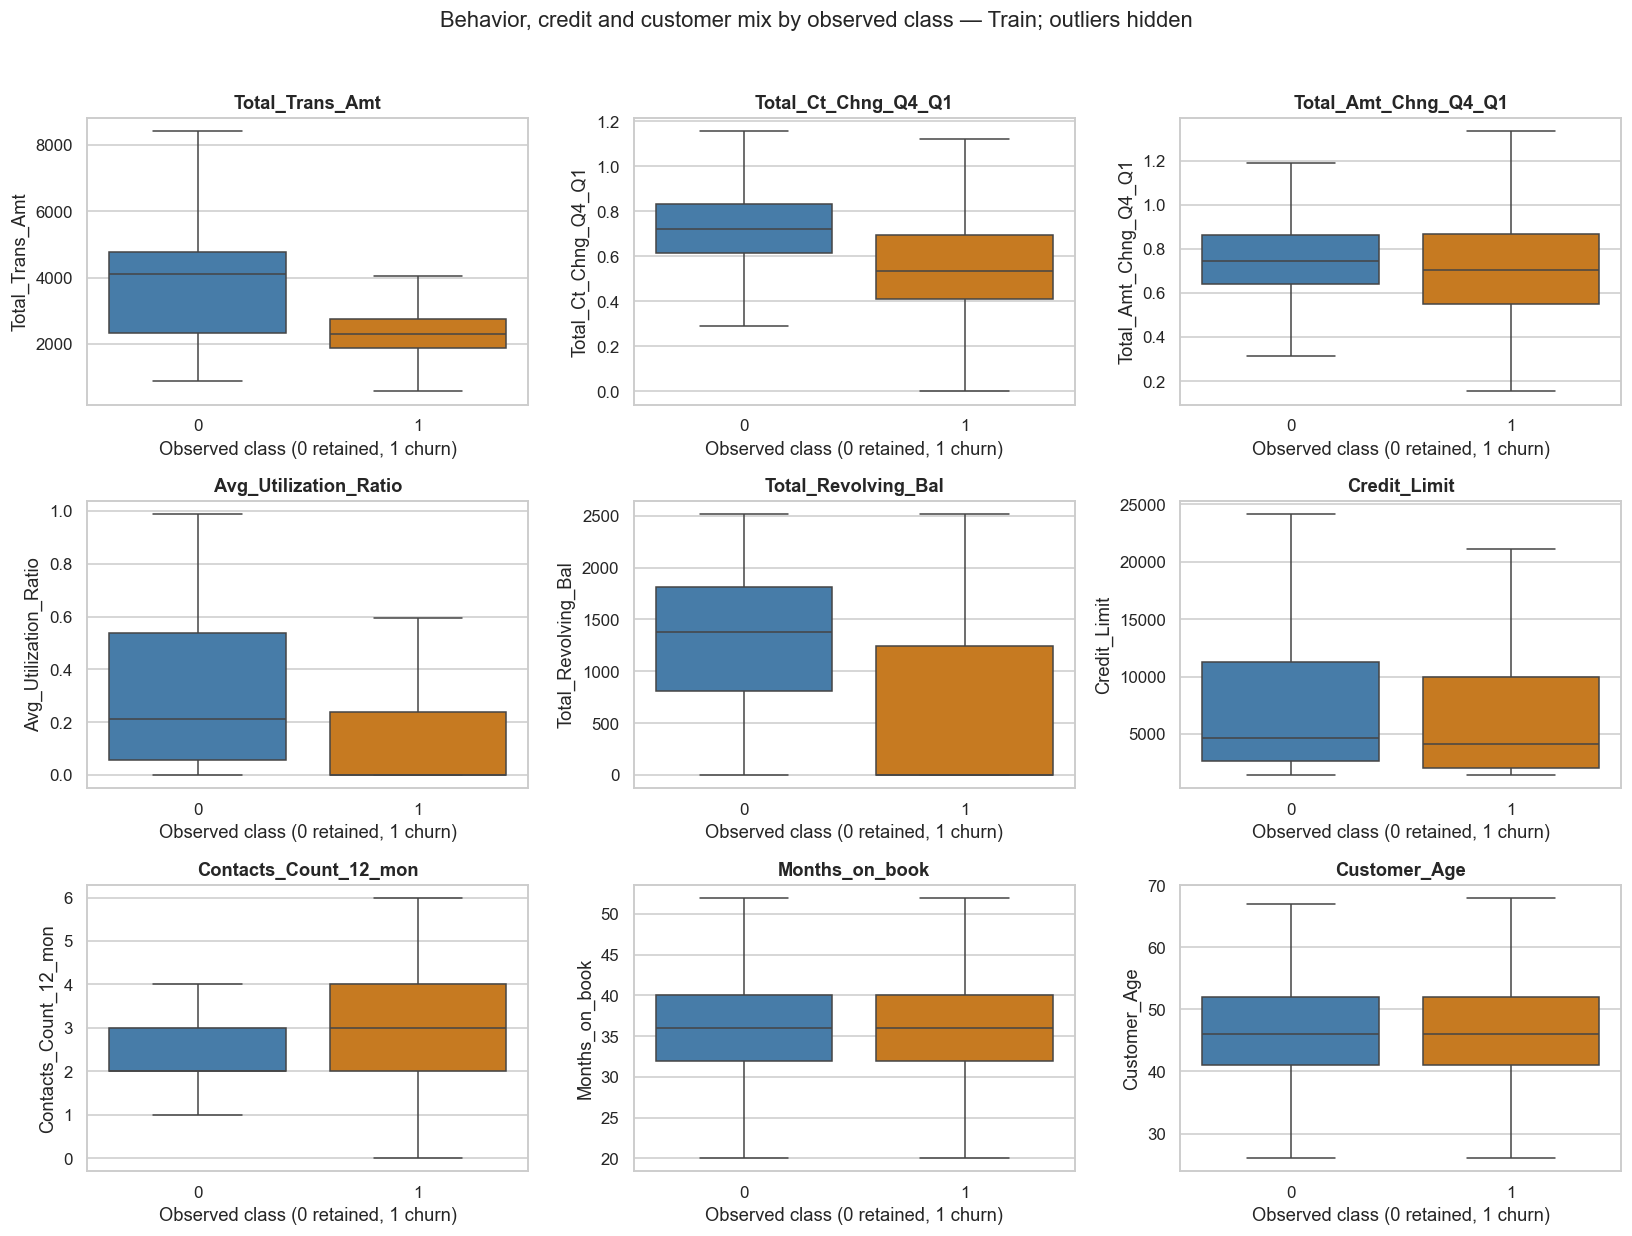

Churn,retained_median,churned_median
Total_Trans_Amt,4098.0000,2312.500
Total_Ct_Chng_Q4_Q1,0.7220,0.533
Total_Amt_Chng_Q4_Q1,0.7430,0.703
Avg_Utilization_Ratio,0.2135,0.000
Total_Revolving_Bal,1375.0000,0.000
Credit_Limit,4644.0000,4145.500
Contacts_Count_12_mon,2.0000,3.000
Months_on_book,36.0000,36.000
Customer_Age,46.0000,46.000


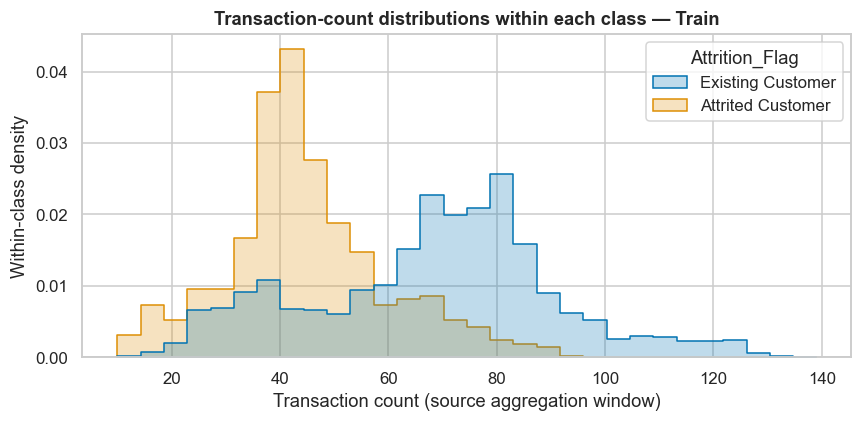

,n,churn_count,churn_rate,ci_low,ci_high,small_n
Card_Category,,,,,,
Blue,5664,910,0.160664,0.151331,0.170457,False
Gold,74,15,0.202703,0.126870,0.307880,False
Platinum,11,3,0.272727,0.097459,0.565650,True
Silver,327,48,0.146789,0.112536,0.189245,False


,n,churn_count,churn_rate,ci_low,ci_high,small_n
Income_Category,,,,,,
$120K +,439,74,0.168565,0.136454,0.206427,False
$40K - $60K,1071,151,0.140990,0.121428,0.163118,False
$60K - $80K,818,115,0.140587,0.118443,0.166091,False
$80K - $120K,925,137,0.148108,0.126673,0.172454,False
Less than $40K,2164,385,0.177911,0.162373,0.194591,False
Unknown,659,114,0.172989,0.146027,0.203742,False


,n,churn_count,churn_rate,ci_low,ci_high,small_n
Marital_Status,,,,,,
Divorced,450,69,0.153333,0.122989,0.189547,False
Married,2814,432,0.153518,0.140672,0.167309,False
Single,2363,392,0.165891,0.151437,0.181429,False
Unknown,449,83,0.184855,0.151676,0.223382,False


,n,churn_count,churn_rate,ci_low,ci_high,small_n
Education_Level,,,,,,
College,607,94,0.154860,0.128259,0.185802,False
Doctorate,268,57,0.212687,0.167932,0.265561,False
Graduate,1830,287,0.156831,0.140890,0.174209,False
High School,1246,178,0.142857,0.124524,0.163386,False
Post-Graduate,304,56,0.184211,0.144667,0.231635,False
Uneducated,884,147,0.166290,0.143199,0.192268,False
Unknown,937,157,0.167556,0.145010,0.192817,False


,n,churn_count,churn_rate,ci_low,ci_high,small_n
Gender,,,,,,
F,3215,570,0.177294,0.164479,0.190879,False
M,2861,406,0.141908,0.129601,0.155176,False


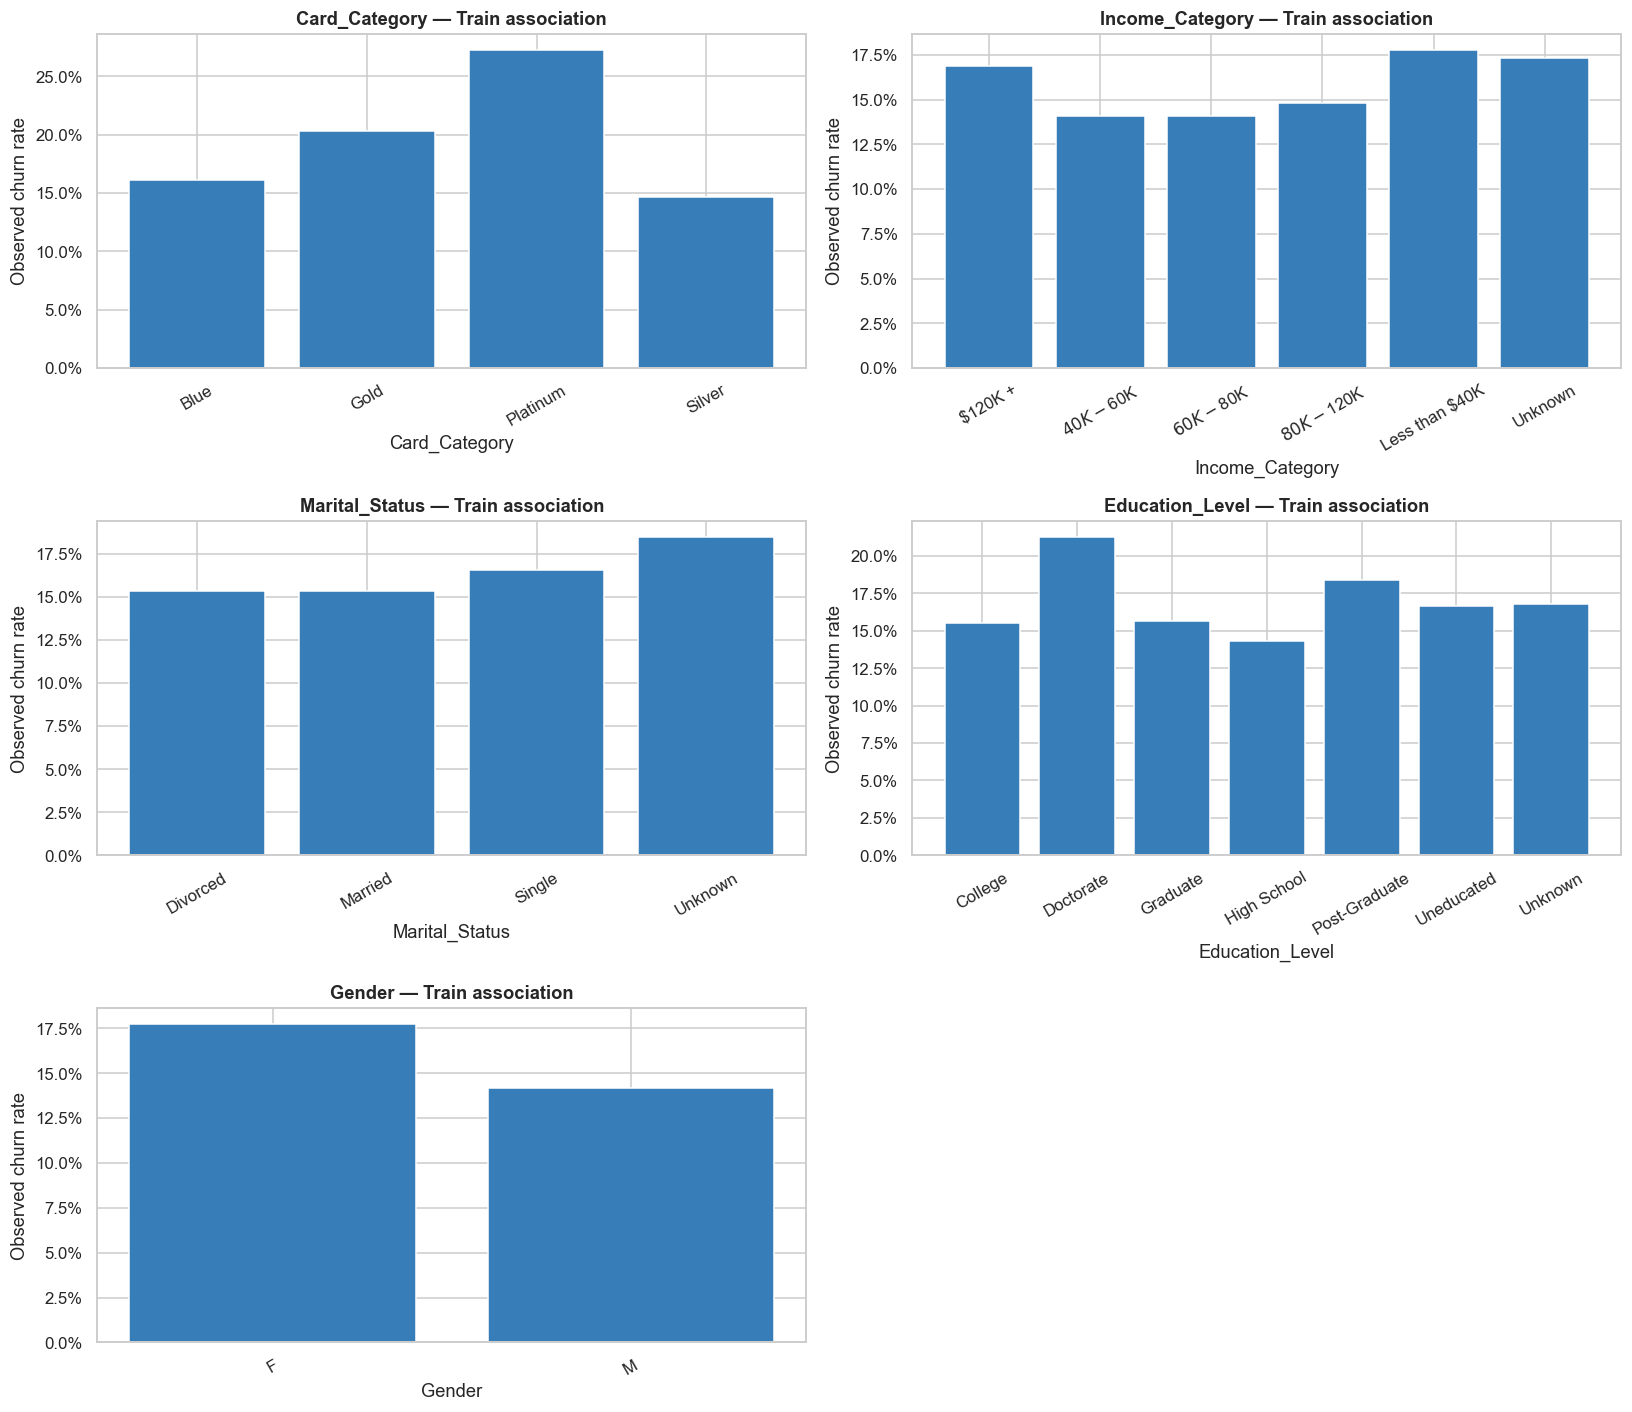

Observational training-set associations only. Customer mix, confounding, label timing, and correlated behaviors may explain differences; association does not establish causation. All displayed categorical rates must be read with their table counts and small-n flags.

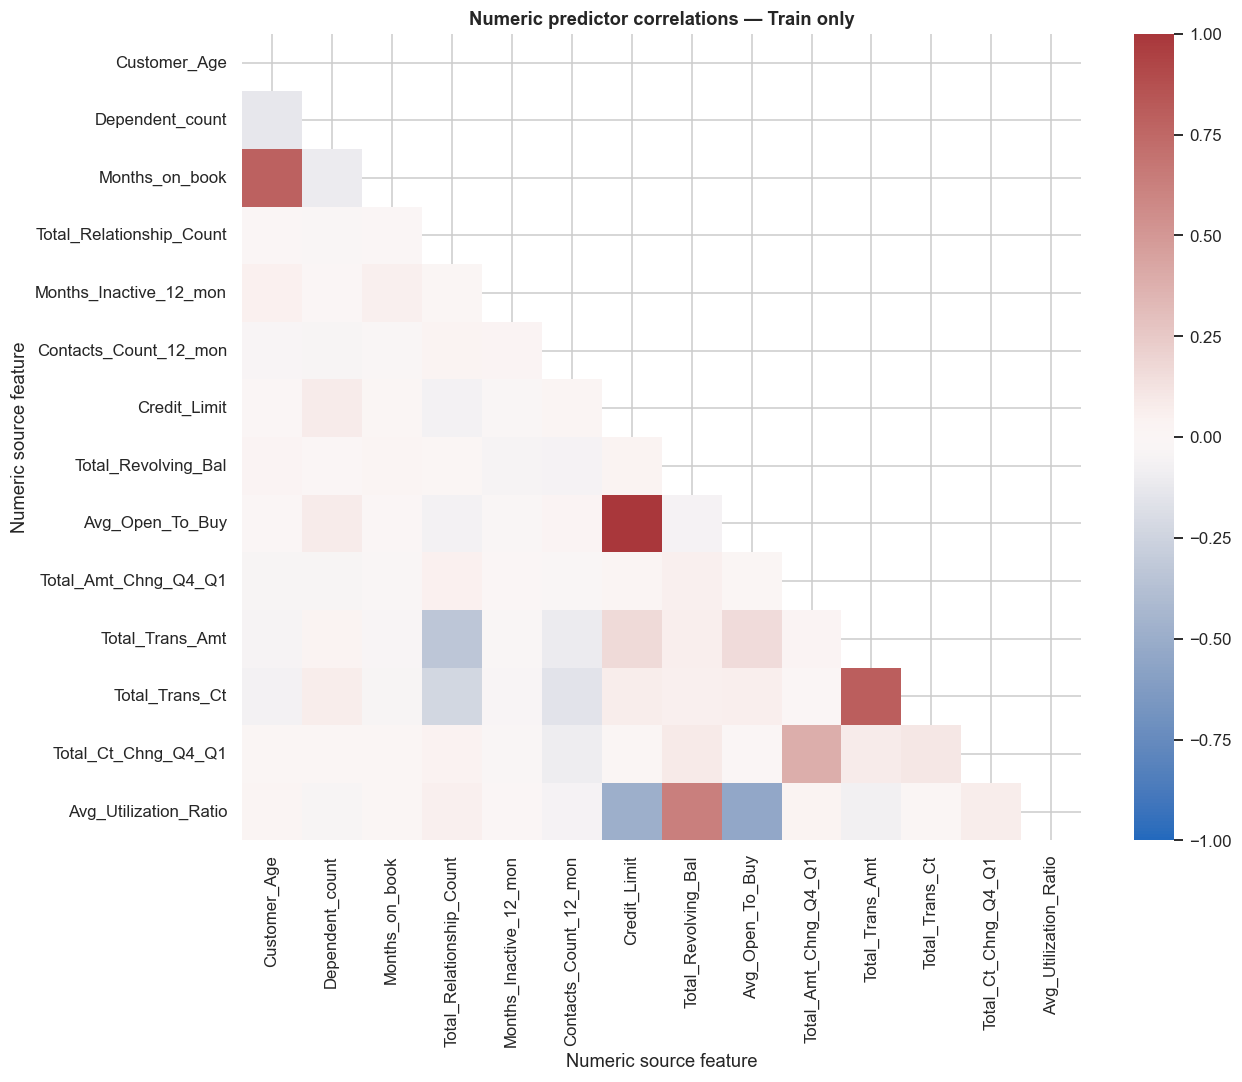

**Interpretation:** Boxplots show within-class spread; the correlation matrix reveals overlapping predictor information. **Business implication:** Combine behavior and relationship context in a validated model; do not convert one cross-tab into an intervention rule. **Limitation:** No significance or causal claims are inferred from these exploratory plots.

In [8]:
numeric_eda_fields = [
    "Total_Trans_Amt", "Total_Ct_Chng_Q4_Q1", "Total_Amt_Chng_Q4_Q1",
    "Avg_Utilization_Ratio", "Total_Revolving_Bal", "Credit_Limit",
    "Contacts_Count_12_mon", "Months_on_book", "Customer_Age",
]
fig, axes = plt.subplots(3, 3, figsize=(15, 11))
for ax, field in zip(axes.flat, numeric_eda_fields):
    sns.boxplot(data=train, x="Churn", y=field, hue="Churn", palette=["#377eb8", "#e17c05"], dodge=False, showfliers=False, ax=ax)
    if ax.get_legend() is not None:
        ax.get_legend().remove()
    ax.set(title=field, xlabel="Observed class (0 retained, 1 churn)", ylabel=field)
fig.suptitle("Behavior, credit and customer mix by observed class — Train; outliers hidden", y=1.02)
save_figure("eda_numeric_boxplots")
display(train.groupby("Churn")[numeric_eda_fields].median().T.rename(columns={0: "retained_median", 1: "churned_median"}))
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(data=train, x="Total_Trans_Ct", hue="Attrition_Flag", stat="density", common_norm=False, bins=30, element="step", ax=ax)
ax.set(title="Transaction-count distributions within each class — Train", xlabel="Transaction count (source aggregation window)", ylabel="Within-class density")
save_figure("eda_transaction_distribution")

categorical_eda_fields = ["Card_Category", "Income_Category", "Marital_Status", "Education_Level", "Gender"]
categorical_segments = {}
fig, axes = plt.subplots(3, 2, figsize=(15, 13))
for ax, field in zip(axes.flat, categorical_eda_fields):
    table = segment_summary(train, field)
    categorical_segments[field] = table
    display(table)
    ax.bar(table.index.astype(str), table["churn_rate"], color="#377eb8")
    ax.set(title=field + " — Train association", xlabel=field, ylabel="Observed churn rate")
    ax.tick_params(axis="x", rotation=30)
    ax.yaxis.set_major_formatter(PercentFormatter(1))
axes.flat[-1].axis("off")
save_figure("eda_categorical_rates")
report(ASSOCIATION_NOTE + " All displayed categorical rates must be read with their table counts and small-n flags.")

correlation_fields = [f for f in field_info if f in train.select_dtypes(include=np.number) and f != "CLIENTNUM"]
correlations = train[correlation_fields].corr()
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(correlations, mask=np.triu(np.ones_like(correlations, dtype=bool)), center=0, vmin=-1, vmax=1, cmap="vlag", ax=ax)
ax.set(title="Numeric predictor correlations — Train only", xlabel="Numeric source feature", ylabel="Numeric source feature")
save_figure("eda_numeric_correlations")
report("**Interpretation:** Boxplots show within-class spread; the correlation matrix reveals overlapping predictor information. **Business implication:** Combine behavior and relationship context in a validated model; do not convert one cross-tab into an intervention rule. **Limitation:** No significance or causal claims are inferred from these exploratory plots.")

### Why multivariate validation is necessary
Crossing gender × plan-like attributes × demographics × behavioral bands creates combinatorial growth in cells. Many cells then contain few customers, producing unstable rates and multiple-testing problems. Searching many slices also makes accidental extremes likely. This notebook does not run a battery of exploratory chi-square tests. If such a test is added, inspect expected cell counts first; sparse expected counts make the asymptotic chi-square approximation unreliable. Validated multivariate ML helps combine predictors and measure generalization, but does not remove confounding or establish causation.

## 4. Leakage audit — What must not enter the model?
**Question.** Can a feature reveal the answer or contaminate evaluation?

| Leakage type | Mechanism | Control here |
|---|---|---|
| Target | Feature directly reveals outcome | Drop source label, `Churn`, both Naive Bayes outputs |
| Temporal | Post-decision information is included | Cannot verify without timestamps; explicitly limit claims |
| Preprocessing | Imputer/scaler/encoder/resampler sees evaluation rows | Fit preprocessing inside every training fold |
| Group | Same customer crosses partitions | Unique CLIENTNUM and disjoint IDs; ID excluded |

**Method.** Pattern-match source classifier columns, enforce a known predictor schema, inspect retained field names/types and exact target copies on Train. **Result.** Print every exclusion and retained input. **Business implication.** Strong metrics are useful only after target-related shortcuts are removed.
**Limitation.** A schema/name/value audit cannot prove that source features predate attrition.

In [9]:
nb_columns = [c for c in data.columns if "naive_bayes_classifier_attrition_flag" in c.lower()]
if len(nb_columns) != 2:
    warnings.warn(f"Expected historically two Naive Bayes columns; found {len(nb_columns)}. All matches will be excluded.")
excluded = ["CLIENTNUM", "Attrition_Flag", "Churn"] + nb_columns
for field in excluded:
    reason = "customer key / group integrity only" if field == "CLIENTNUM" else "target or target-related source output"
    print("Excluded:", field, "|", reason)
predictor_columns = [c for c in data.columns if c not in excluded]
allowed_predictors = set(field_info) - {"CLIENTNUM", "Attrition_Flag"}
assert set(predictor_columns) == allowed_predictors, f"Source schema changed. Review unexpected/missing predictors: {set(predictor_columns) ^ allowed_predictors}"
assert not any(any(token in c.lower() for token in ["churn", "attrition", "naive_bayes", "target", "prediction"]) for c in predictor_columns)
for field in predictor_columns:
    if pd.api.types.is_numeric_dtype(train[field]):
        assert not np.array_equal(train[field].to_numpy(), train["Churn"].to_numpy()), f"Possible exact target copy: {field}"
        assert not np.array_equal(train[field].to_numpy(), 1-train["Churn"].to_numpy()), f"Possible inverted target copy: {field}"
display(data_dictionary[data_dictionary["field"].isin(predictor_columns)])
X_train = data.loc[train_idx, predictor_columns].copy()
X_validation = data.loc[validation_idx, predictor_columns].copy()
X_test = data.loc[test_idx, predictor_columns].copy()
y_train = data.loc[train_idx, "Churn"].copy()
y_validation = data.loc[validation_idx, "Churn"].copy()
y_test = data.loc[test_idx, "Churn"].copy()
assert not (set(excluded) & set(X_train.columns))
print("Retained predictor count:", len(predictor_columns))

Excluded: CLIENTNUM | customer key / group integrity only
Excluded: Attrition_Flag | target or target-related source output
Excluded: Churn | target or target-related source output
Excluded: Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1 | target or target-related source output
Excluded: Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2 | target or target-related source output


,field,dtype,group,meaning,unit,window_or_note
2,Customer_Age,int64,Identity / demographics,Customer age,years,Measurement date unspecified
3,Gender,str,Identity / demographics,Recorded gender category,category,Collection definition unspecified
4,Dependent_count,int64,Identity / demographics,Recorded dependents,count,Measurement date unspecified
5,Education_Level,str,Identity / demographics,Education category,category,Unknown is explicit
6,Marital_Status,str,Identity / demographics,Marital-status category,category,Unknown is explicit
7,Income_Category,str,Identity / demographics,Income band as recorded,source category,Currency/period unspecified in table
8,Card_Category,str,Plan / relationship,Card tier,category,Snapshot
9,Months_on_book,int64,Plan / relationship,Length of relationship,months,As-of date unspecified
10,Total_Relationship_Count,int64,Plan / relationship,Products/relationships held,count,As-of date unspecified
11,Months_Inactive_12_mon,int64,Behavior / transactions,Inactive months,months,12-month label; calendar boundaries unspecified


Retained predictor count: 19


## 5. Feature engineering — How does behavior change?
**Question.** Can two transparent ratios summarize engagement context?
**Method.** Use row-local calculations:
$$\mathrm{average\_ticket}=\frac{\mathrm{Total\_Trans\_Amt}}{\max(\mathrm{Total\_Trans\_Ct},1)},\qquad
\mathrm{contact\_ratio}=\frac{\mathrm{Contacts\_Count\_12\_mon}}{\max(\mathrm{Total\_Relationship\_Count},1)}.$$
Average ticket describes amount per transaction; contact ratio describes contact intensity per relationship. Changes in spending mix or contact burden might accompany disengagement. For zero transaction counts, average ticket is a computational proxy under the requested denominator rule, not a literal observed ticket size.

**Result.** Check exact numeric duplicates and strongest training correlations against source features. No ratio is added that simply reconstructs utilization. **Interpretation.** Ratios share information with their parent fields; importance may be split across them.
**Business implication.** Apply the same reusable transformer in every pipeline.
**Limitation.** Row-local engineered features are mechanically leakage-safe relative to the snapshot, but cannot prove temporal eligibility for a real scoring date. All inputs would need to be known at that date. Missing parents remain missing for fold-specific imputation; division must not introduce new missing or infinite values.

In [10]:
def add_snapshot_features(frame):
    result = frame.copy()
    definitions = {
        "average_ticket": ("Total_Trans_Amt", "Total_Trans_Ct"),
        "contact_ratio": ("Contacts_Count_12_mon", "Total_Relationship_Count"),
    }
    for name, (numerator, denominator) in definitions.items():
        source_missing = result[[numerator, denominator]].isna().any(axis=1)
        result[name] = result[numerator] / result[denominator].clip(lower=1)
        assert result.loc[~source_missing, name].notna().all(), f"Division introduced NaN in {name}."
        assert np.isfinite(result[name].dropna()).all(), f"Non-finite engineered values in {name}."
    return result

feature_preview = add_snapshot_features(X_train)
numeric_columns = feature_preview.select_dtypes(include=np.number).columns.tolist()
categorical_columns = feature_preview.select_dtypes(exclude=np.number).columns.tolist()
assert not feature_preview.isna().all().any(), "Entirely missing training field requires source review."
duplicate_ratio_checks = []
for ratio in ["average_ticket", "contact_ratio"]:
    duplicate_sources = [c for c in X_train.select_dtypes(include=np.number) if np.allclose(feature_preview[ratio], X_train[c], equal_nan=True)]
    duplicate_ratio_checks.append({"engineered_feature": ratio, "exact_duplicate_source_fields": duplicate_sources})
display(pd.DataFrame(duplicate_ratio_checks))
display(feature_preview[numeric_columns].corr()[["average_ticket", "contact_ratio"]].drop(index=["average_ticket", "contact_ratio"]).abs().sort_values("average_ticket", ascending=False))
print("Numeric fields:", numeric_columns)
print("Categorical fields:", categorical_columns)
display(feature_preview[["average_ticket", "contact_ratio"]].describe().T)

,engineered_feature,exact_duplicate_source_fields
0,average_ticket,[]
1,contact_ratio,[]


,average_ticket,contact_ratio
Total_Trans_Amt,0.905982,0.197453
Total_Trans_Ct,0.534976,0.091927
Total_Relationship_Count,0.332408,0.658351
Credit_Limit,0.173039,0.059711
Avg_Open_To_Buy,0.169499,0.063643
Avg_Utilization_Ratio,0.096408,0.080632
Total_Ct_Chng_Q4_Q1,0.079060,0.085538
Contacts_Count_12_mon,0.073845,0.498224
Total_Amt_Chng_Q4_Q1,0.069613,0.059094
Customer_Age,0.039939,0.012358


Numeric fields: ['Customer_Age', 'Dependent_count', 'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal', 'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio', 'average_ticket', 'contact_ratio']
Categorical fields: ['Gender', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category']


,count,mean,std,min,25%,50%,75%,max
average_ticket,6076.0,62.243942,25.801724,23.805556,47.510852,55.855641,65.257251,180.058824
contact_ratio,6076.0,0.818828,0.668252,0.000000,0.400000,0.666667,1.000000,6.000000


### Event-level features that this snapshot cannot supply
With timestamped history, RFM means **Recency** since last event, **Frequency** of activity, and **Monetary** amount over a specified window. Use 7/30/90-day counts, rolling averages, trend/slope features, and recent-versus-previous changes such as
$\Delta\mathrm{sessions}=\mathrm{sessions}_{\mathrm{recent\ 30d}}-\mathrm{sessions}_{\mathrm{previous\ 30d}}$.

```text
Timestamped events
      ↓
As-of join: event_time < t0
      ↓
7d / 30d / 90d windows
      ↓
RFM / rolling / trend / shifts
      ↓
Fold-safe encoding
      ↓
One row per customer snapshot
```
Aggregate events without using information after the decision point. Repeated snapshots also require customer-aware temporal validation. No fake rolling histories or recency values are calculated from these single customer rows.

## 6. Preprocessing architecture — What is learned inside each fold?
**Question.** Can all candidates share a reproducible, leakage-controlled pipeline?
**Method.** Row-local features → ColumnTransformer → estimator. Numeric: median imputation then StandardScaler. Categorical: most-frequent imputation then one-hot encoding with unknown-category tolerance. Detect the installed encoder API; keep dense output for this small dataset and TreeSHAP.
**Result.** Each estimator receives a fresh cloned preprocessor. **Interpretation.** Trees do not require standardization; using it consistently supports the linear baseline and simplifies comparison.
**Business implication.** New snapshots receive exactly the fitted transformation.
**Limitation.** Unseen categories are encoded as all-zero within that field; their arrival should also trigger monitoring. Unknown remains a meaningful observed category. No oversampling or feature selection occurs outside a fold.

In [11]:
encoder_options = {"handle_unknown": "ignore"}
if "sparse_output" in inspect.signature(OneHotEncoder).parameters:
    encoder_options["sparse_output"] = False
else:
    encoder_options["sparse"] = False
numeric_pipeline = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())])
categorical_pipeline = Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("encoder", OneHotEncoder(**encoder_options))])
preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_columns),
    ("categorical", categorical_pipeline, categorical_columns),
], remainder="drop", sparse_threshold=0)

def make_pipeline(estimator):
    return Pipeline([
        ("features", FunctionTransformer(add_snapshot_features, validate=False)),
        ("preprocess", clone(preprocessor)),
        ("model", estimator),
    ])

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
cv_splits = list(cv.split(X_train, y_train))
for fit_rows, score_rows in cv_splits:
    assert set(fit_rows).isdisjoint(score_rows)
    assert y_train.iloc[fit_rows].nunique() == y_train.iloc[score_rows].nunique() == 2
print("Preprocessing is inside each estimator Pipeline; CV uses identical training-only folds.")

Preprocessing is inside each estimator Pipeline; CV uses identical training-only folds.


## 7. Baseline models — Who is at risk?
**Question.** How much do interpretable baselines improve on majority prediction?
**Method.** Compare the same data, the same 3-fold stratified CV within the historical snapshot, and the same primary metric: Average Precision (AP).

* **Majority class:** always predicts the training majority; no useful ranking.
* **Balanced logistic regression:** $p(\mathrm{churn}\mid x)=1/(1+e^{-z})$, $z=\beta_0+\sum_j\beta_jx_j$. An odds ratio is $OR_j=e^{\beta_j}$. Odds are not probabilities; coefficients describe conditional model associations, not causal effects.
* **Controlled decision tree:** splits on rules, with depth/leaf limits to reduce memorization.
* **Balanced Random Forest (primary):** averages tree probabilities from bootstrap samples and random candidate-feature subsets; class weighting increases the minority class's fitting influence.

**Result.** Training CV scores are computed below; validation comparison follows tuning. **Interpretation / business implication.** AP measures precision along the recall path and helps identify candidates that rank churners early.
**Limitation.** CV estimates remain specific to the source snapshot. Choosing the best CV score introduces selection optimism; CV fold standard deviations are not confidence intervals.

## 8. Imbalanced classification — Accuracy is insufficient
**Question.** How should fitting treat the minority churn class?
**Method.** Class weighting retains real observations; conceptually $w_c=N/(K N_c)$. sklearn calculates balanced weights within each fit. No synthetic observations are the default.

**SMOTE** interpolates minority neighbors; **ADASYN** allocates more synthetic points near difficult regions. Applied before splitting, either contaminates validation. Naïve interpolation of category codes or one-hot profiles can create implausible customers. If tested later, a categorical-aware method such as SMOTENC is a more defensible sensitivity experiment, using an imbalanced-learn Pipeline and resampling training folds only.

**Interpretation.** Weighting changes the fitting objective and can distort raw probability calibration. **Business implication.** Inspect probability quality as well as rankings. **Limitation.** Synthetic sampling is not assumed to improve generalization; this notebook compares weighted models without claiming an untested sampling benefit.

In [12]:
candidate_pipelines = {
    "Majority baseline": make_pipeline(DummyClassifier(strategy="most_frequent")),
    "Logistic Regression": make_pipeline(LogisticRegression(class_weight="balanced", max_iter=2000, random_state=RANDOM_STATE)),
    "Decision Tree": make_pipeline(DecisionTreeClassifier(max_depth=5, min_samples_leaf=20, class_weight="balanced", random_state=RANDOM_STATE)),
    "Random Forest baseline": make_pipeline(RandomForestClassifier(n_estimators=150, max_depth=10, min_samples_leaf=2, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=1)),
}

# Optional imports only: no package installation and no test-driven benchmark decisions.
try:
    from xgboost import XGBClassifier
except (ImportError, OSError) as exc:
    print(f"XGBoost unavailable ({type(exc).__name__}); optional benchmark skipped.")
else:
    candidate_pipelines["XGBoost benchmark"] = make_pipeline(XGBClassifier(
        n_estimators=200, max_depth=3, learning_rate=0.05, subsample=0.9,
        colsample_bytree=0.9, eval_metric="logloss", tree_method="hist", n_jobs=1,
        random_state=RANDOM_STATE,
    ))
    versions["xgboost"] = metadata.version("xgboost")
try:
    from lightgbm import LGBMClassifier
except (ImportError, OSError) as exc:
    print(f"LightGBM unavailable ({type(exc).__name__}); optional benchmark skipped.")
else:
    candidate_pipelines["LightGBM benchmark"] = make_pipeline(LGBMClassifier(
        n_estimators=200, num_leaves=15, learning_rate=0.05, min_child_samples=20,
        class_weight="balanced", verbosity=-1, n_jobs=1, random_state=RANDOM_STATE,
    ))
    versions["lightgbm"] = metadata.version("lightgbm")

scoring = {"ap": "average_precision", "roc_auc": "roc_auc", "recall": "recall", "f1": "f1"}
fitted_candidates, cv_rows = {}, []
for name, pipeline in candidate_pipelines.items():
    scores = cross_validate(pipeline, X_train, y_train, cv=cv_splits, scoring=scoring,
                            n_jobs=N_JOBS, error_score="raise", return_train_score=True)
    row = {"Model": name}
    for metric in scoring:
        row[f"CV_{metric}"] = float(np.mean(scores[f"test_{metric}"]))
    row["CV_ap_std"] = float(np.std(scores["test_ap"], ddof=0))
    row["Train_ap"] = float(np.mean(scores["train_ap"]))
    cv_rows.append(row)
    fitted_candidates[name] = clone(pipeline).fit(X_train, y_train)
    print(f"{name}: CV AP = {row['CV_ap']:.4f} ± {row['CV_ap_std']:.4f} (fold SD)")
cv_baselines = pd.DataFrame(cv_rows)
display(cv_baselines.sort_values("CV_ap", ascending=False))

Majority baseline: CV AP = 0.1606 ± 0.0002 (fold SD)
Logistic Regression: CV AP = 0.7701 ± 0.0088 (fold SD)


Decision Tree: CV AP = 0.7561 ± 0.0151 (fold SD)


Random Forest baseline: CV AP = 0.9315 ± 0.0051 (fold SD)


XGBoost benchmark: CV AP = 0.9530 ± 0.0017 (fold SD)


LightGBM benchmark: CV AP = 0.9638 ± 0.0027 (fold SD)


,Model,CV_ap,CV_roc_auc,CV_recall,CV_f1,CV_ap_std,Train_ap
5,LightGBM benchmark,0.963839,0.991836,0.919062,0.894420,0.002716,0.999278
4,XGBoost benchmark,0.953016,0.989004,0.844244,0.885033,0.001740,0.984720
3,Random Forest baseline,0.931457,0.985138,0.856574,0.865430,0.005122,0.996372
1,Logistic Regression,0.770088,0.934071,0.857593,0.667714,0.008817,0.775886
2,Decision Tree,0.756127,0.946302,0.909819,0.727848,0.015127,0.837446
0,Majority baseline,0.160632,0.500000,0.000000,0.000000,0.000195,0.160632


### Optional advanced benchmarks
XGBoost uses boosted, regularized trees (often depth/level-wise growth); LightGBM uses histogram-based training and commonly leaf-wise growth. They use identical folds and AP here. The optional XGBoost benchmark uses its unweighted objective, while LightGBM uses balanced weights; these are stated model recipes, not a controlled test of the weighting effect. No global training prevalence is passed as a class-weight estimate into CV folds. A model is not better merely because it is more advanced.

## 9. Hyperparameter optimization — Is the Random Forest robust?
**Question.** Which course-aligned forest configuration best ranks churners within Train?
**Method.** Twelve parameter combinations × three folds; AP scoring; preprocessing refit within every fold. Compare train AP with held-out fold AP for overfitting signals.
**Result.** Show best parameters and top candidates. **Interpretation.** Larger train-minus-CV gaps suggest optimism but do not alone identify a bad model.
**Business implication.** Choose the forest variant by Train CV before using Validation for the final family decision and action threshold.
**Limitation.** This finite search is not a global optimum; an independent snapshot/time horizon would be required for production validation.

In [13]:
parameter_grid = {
    "model__n_estimators": [150],
    "model__max_depth": [5, 10, None],
    "model__min_samples_leaf": [2, 8],
    "model__max_features": ["sqrt", 0.6],
}
forest_search = GridSearchCV(
    make_pipeline(RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE, n_jobs=1)),
    parameter_grid, cv=cv_splits, scoring="average_precision", n_jobs=N_JOBS,
    return_train_score=True, error_score="raise", refit=True,
)
forest_search.fit(X_train, y_train)
search_results = pd.DataFrame(forest_search.cv_results_)
search_results["train_cv_gap"] = search_results["mean_train_score"] - search_results["mean_test_score"]
display(search_results.sort_values("rank_test_score")[["params", "mean_test_score", "std_test_score", "mean_train_score", "train_cv_gap"]].head(8))
print("Best forest parameters:", forest_search.best_params_)
print("Best mean CV AP:", forest_search.best_score_)
search_results.to_csv(OUTPUT_DIR / "cv_results.csv", index=False)
fitted_candidates["Random Forest tuned"] = forest_search.best_estimator_
best_search_index = forest_search.best_index_
cv_rows.append({
    "Model": "Random Forest tuned", "CV_ap": forest_search.best_score_,
    "CV_ap_std": search_results.loc[best_search_index, "std_test_score"],
    "Train_ap": search_results.loc[best_search_index, "mean_train_score"],
})
forest_baseline_ap = float(cv_baselines.set_index("Model").loc["Random Forest baseline", "CV_ap"])
course_forest_name = "Random Forest tuned" if forest_search.best_score_ > forest_baseline_ap + 1e-12 else "Random Forest baseline"
course_forest_pipeline = fitted_candidates[course_forest_name]
empirical_cv_leader = max(cv_rows, key=lambda row: row["CV_ap"])["Model"]
report(f"**Forest variant locked using Train only:** {course_forest_name}. **Highest mean CV AP among evaluated recipes:** {empirical_cv_leader}. Validation will now apply the predeclared final-model rule; Test remains unopened.")

,params,mean_test_score,std_test_score,mean_train_score,train_cv_gap
8,"{'model__max_depth': None, 'model__max_feature...",0.942576,0.001707,0.999809,0.057233
10,"{'model__max_depth': None, 'model__max_feature...",0.939583,0.004407,0.999591,0.060009
6,"{'model__max_depth': 10, 'model__max_features'...",0.935720,0.006246,0.996140,0.060421
11,"{'model__max_depth': None, 'model__max_feature...",0.932599,0.003455,0.985433,0.052834
7,"{'model__max_depth': 10, 'model__max_features'...",0.932283,0.003563,0.984424,0.052141
4,"{'model__max_depth': 10, 'model__max_features'...",0.931457,0.005122,0.996372,0.064915
9,"{'model__max_depth': None, 'model__max_feature...",0.922420,0.003261,0.982547,0.060128
5,"{'model__max_depth': 10, 'model__max_features'...",0.922176,0.004912,0.979889,0.057713


Best forest parameters: {'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 2, 'model__n_estimators': 150}
Best mean CV AP: 0.9425760403949496


**Forest variant locked using Train only:** Random Forest tuned. **Highest mean CV AP among evaluated recipes:** LightGBM benchmark. Validation will now apply the predeclared final-model rule; Test remains unopened.

### Model comparison and logistic associations
**Question.** How do training-CV and validation rankings compare?
**Method.** Score fitted candidates on Validation only. No candidate is scored on Test here. Logistic coefficients are shown after encoding: numeric coefficients correspond to one training-standard-deviation change; each dummy coefficient multiplies odds with other encoded coordinates held fixed. Because full one-hot encoding, regularization and correlated fields complicate contrasts, coefficients are descriptive model parameters, not causal effects or independent importance estimates. For two levels of one category, the modeled odds ratio is exp(β_levelA − β_levelB).
**Result / interpretation.** The comparison table distinguishes the strongest predictive candidate from the course-aligned forest. **Business implication.** Use Validation to select the final model and its illustrative decision threshold. **Limitation.** Validation is reused for model and threshold selection and is not the final unbiased estimate. The fresh Test report accounts for this selection at the level of one frozen policy.

In [14]:
def churn_probability(pipeline, frame):
    classes = np.asarray(pipeline.named_steps["model"].classes_)
    matches = np.flatnonzero(classes == 1)
    assert len(matches) == 1, "Churn=1 class is not uniquely identified."
    probability = pipeline.predict_proba(frame)[:, int(matches[0])]
    assert np.isfinite(probability).all() and ((probability >= 0) & (probability <= 1)).all()
    return probability

validation_probabilities = {name: churn_probability(model, X_validation) for name, model in fitted_candidates.items()}
model_comparison = pd.DataFrame(cv_rows)
model_comparison["Validation_AP"] = model_comparison["Model"].map(lambda name: average_precision_score(y_validation, validation_probabilities[name]))
model_comparison["Validation_ROC_AUC"] = model_comparison["Model"].map(lambda name: roc_auc_score(y_validation, validation_probabilities[name]))
model_comparison["Validation_Brier_Score"] = model_comparison["Model"].map(lambda name: brier_score_loss(y_validation, validation_probabilities[name]))
selection_pool = model_comparison[~model_comparison["Model"].str.startswith("Random Forest") | model_comparison["Model"].eq(course_forest_name)]
validation_leader = selection_pool.sort_values(["Validation_AP", "CV_ap", "Validation_Brier_Score"], ascending=[False, False, True]).iloc[0]
forest_validation_row = model_comparison.set_index("Model").loc[course_forest_name]
forest_competitive = (forest_validation_row["Validation_AP"] >= validation_leader["Validation_AP"] - 0.01
                      and forest_validation_row["Validation_Brier_Score"] <= validation_leader["Validation_Brier_Score"] + 0.02)
final_model_name = course_forest_name if forest_competitive else validation_leader["Model"]
final_model = fitted_candidates[final_model_name]
model_comparison["Selected_primary"] = model_comparison["Model"].eq(final_model_name)
model_comparison = model_comparison.sort_values("CV_ap", ascending=False)
display(model_comparison)
model_comparison.to_csv(OUTPUT_DIR / "model_comparison.csv", index=False)
validation_probability = validation_probabilities[final_model_name]
validation_ap = average_precision_score(y_validation, validation_probability)
validation_auc = roc_auc_score(y_validation, validation_probability)

logistic_pipeline = fitted_candidates["Logistic Regression"]
logistic_names = logistic_pipeline.named_steps["preprocess"].get_feature_names_out()
coefficients = logistic_pipeline.named_steps["model"].coef_[0]
logistic_table = pd.DataFrame({"encoded_feature": logistic_names, "coefficient": coefficients, "odds_multiplier": np.exp(coefficients)})
display(logistic_table.assign(abs_coefficient=np.abs(coefficients)).sort_values("abs_coefficient", ascending=False).head(12).drop(columns="abs_coefficient"))
report(f"**Primary validation evidence:** AP {validation_ap:.4f}; ROC-AUC {validation_auc:.4f}. **Interpretation:** Higher ranking quality can focus reviews; it does not estimate how many customers treatment will save.")
report(f"**Final model locked:** {final_model_name}. Validation AP leader among eligible candidates: {validation_leader['Model']}. Course forest competitive under the predeclared AP/Brier margins: {forest_competitive}. TreeSHAP will explain {course_forest_name}; if different, its attributions must not be assigned to the final predictive model.")

,Model,CV_ap,CV_roc_auc,CV_recall,CV_f1,CV_ap_std,Train_ap,Validation_AP,Validation_ROC_AUC,Validation_Brier_Score,Selected_primary
5,LightGBM benchmark,0.963839,0.991836,0.919062,0.894420,0.002716,0.999278,0.967595,0.993184,0.026384,True
4,XGBoost benchmark,0.953016,0.989004,0.844244,0.885033,0.001740,0.984720,0.954549,0.990460,0.026774,False
6,Random Forest tuned,0.942576,NaN,NaN,NaN,0.001707,0.999809,0.943733,0.987405,0.035340,False
3,Random Forest baseline,0.931457,0.985138,0.856574,0.865430,0.005122,0.996372,0.936431,0.985783,0.040918,False
1,Logistic Regression,0.770088,0.934071,0.857593,0.667714,0.008817,0.775886,0.803974,0.937689,0.099024,False
2,Decision Tree,0.756127,0.946302,0.909819,0.727848,0.015127,0.837446,0.781677,0.954209,0.082517,False
0,Majority baseline,0.160632,0.500000,0.000000,0.000000,0.000195,0.160632,0.160494,0.500000,0.160494,False


,encoded_feature,coefficient,odds_multiplier
14,numeric__average_ticket,2.254864,9.533996
11,numeric__Total_Trans_Ct,-1.693875,0.183806
10,numeric__Total_Trans_Amt,-1.614956,0.198899
17,categorical__Gender_M,-0.671743,0.510818
12,numeric__Total_Ct_Chng_Q4_Q1,-0.664062,0.514756
7,numeric__Total_Revolving_Bal,-0.630567,0.532290
36,categorical__Card_Category_Gold,0.597887,1.818272
35,categorical__Card_Category_Blue,-0.536415,0.584841
4,numeric__Months_Inactive_12_mon,0.529402,1.697917
38,categorical__Card_Category_Silver,-0.439372,0.644441


**Primary validation evidence:** AP 0.9676; ROC-AUC 0.9932. **Interpretation:** Higher ranking quality can focus reviews; it does not estimate how many customers treatment will save.

**Final model locked:** LightGBM benchmark. Validation AP leader among eligible candidates: LightGBM benchmark. Course forest competitive under the predeclared AP/Brier margins: False. TreeSHAP will explain Random Forest tuned; if different, its attributions must not be assigned to the final predictive model.

## 10. Validation threshold / decision costs — Which customers are flagged?
**Question.** How does the precision–recall tradeoff change an illustrative decision loss?
**Method.** First inspect validation PR and ROC curves. Precision asks “of flagged customers, how many actually churned?” Recall asks “of actual churners, how many were captured?” Random-ranking precision equals class prevalence. sklearn AP weights precision by recall increments: $AP=\sum_n(R_n-R_{n-1})P_n$; it is not identical to trapezoidal geometric PR area. [sklearn AP documentation](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.average_precision_score.html).

Use **Illustrative teaching costs, not verified company economics:** FN = 5 units, FP = 1 unit.
$$Loss(t)=5FN(t)+FP(t).$$
Evaluate every distinct validation score plus boundary decisions, so the selected threshold minimizes this empirical loss over all available score partitions. Prediction is `probability >= threshold`. Ties prefer fewer flags, then the higher threshold. Including an above-one sentinel represents “flag nobody,” even when a score is exactly 1. Precision with no flags is undefined; tables display 0 by explicit reporting convention.

**Interpretation.** This loss values detection errors; it is not a retention ROI model and does not charge the complete cost of all contacts. **Business implication.** A threshold turns ranking into a review policy under explicit assumptions. **Limitation.** Both costs and policy require prospective business validation. A top-k policy could express a real team capacity, but no real capacity is invented here.

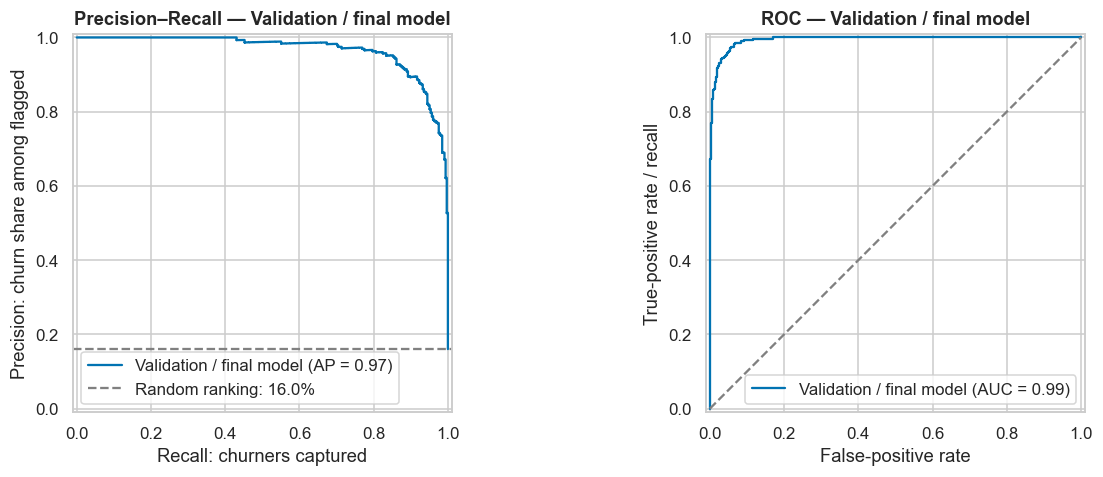

,threshold,TP,FP,FN,TN,precision,recall,F1,flagged_customers,flagged_percentage,decision_loss
0,0.000000,325,1700,0,0,0.160494,1.000000,0.276596,2025,100.000000,1700
184,0.000754,325,1517,0,183,0.176439,1.000000,0.299954,1842,90.962963,1517
368,0.001210,325,1333,0,367,0.196019,1.000000,0.327786,1658,81.876543,1333
552,0.001769,325,1149,0,551,0.220488,1.000000,0.361312,1474,72.790123,1149
737,0.002534,325,964,0,736,0.252133,1.000000,0.402726,1289,63.654321,964
921,0.003916,325,780,0,920,0.294118,1.000000,0.454545,1105,54.567901,780
1105,0.006731,325,596,0,1104,0.352877,1.000000,0.521669,921,45.481481,596
1289,0.015416,325,412,0,1288,0.440977,1.000000,0.612053,737,36.395062,412
1474,0.066995,324,228,1,1472,0.586957,0.996923,0.738883,552,27.259259,233
1658,0.424736,307,61,18,1639,0.834239,0.944615,0.886003,368,18.172840,151


,threshold,TP,FP,FN,TN,precision,recall,F1,flagged_customers,flagged_percentage,decision_loss
Selected policy,0.271024,317.0,95.0,8.0,1605.0,0.769417,0.975385,0.860244,412.0,20.345679,135.0
0.50 reference only,0.500000,303.0,48.0,22.0,1652.0,0.863248,0.932308,0.896450,351.0,17.333333,158.0


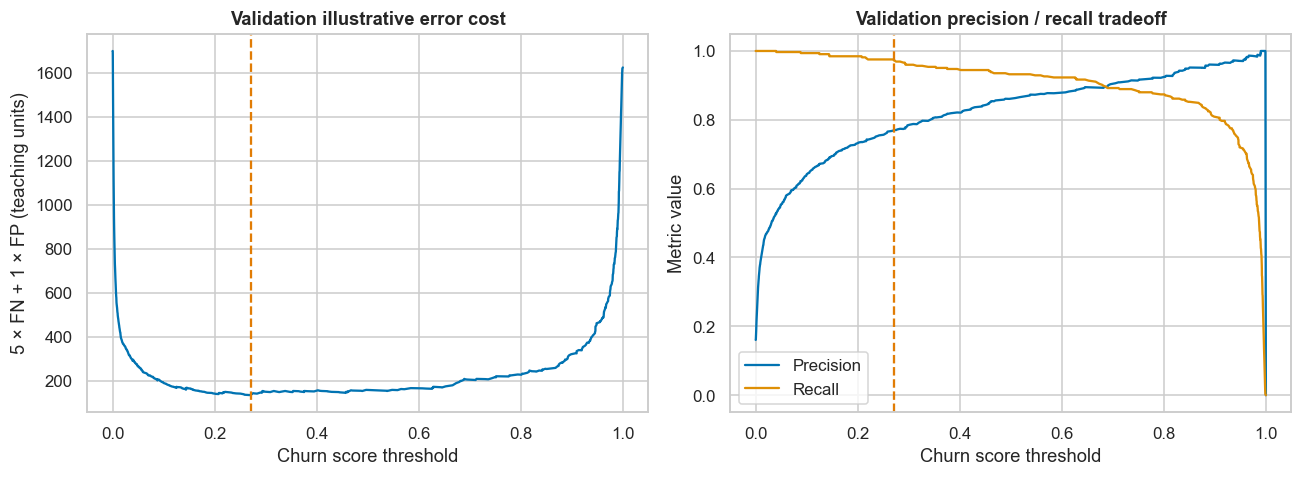

**Frozen decision rule:** Flag when LightGBM benchmark churn score ≥ 0.271024. Validation loss = 135 teaching units; 20.3% flagged. Precision = 76.9%; recall = 97.5%. Neither the fitted model nor threshold will change after Test is opened.

In [15]:
def ranking_figures(actual, probability, label, filename):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    PrecisionRecallDisplay.from_predictions(actual, probability, ax=axes[0], name=label)
    axes[0].axhline(np.mean(actual), linestyle="--", color="gray", label=f"Random ranking: {np.mean(actual):.1%}")
    axes[0].set(title=f"Precision–Recall — {label}", xlabel="Recall: churners captured", ylabel="Precision: churn share among flagged")
    axes[0].legend(loc="lower left")
    RocCurveDisplay.from_predictions(actual, probability, ax=axes[1], name=label)
    axes[1].plot([0, 1], [0, 1], "--", color="gray")
    axes[1].set(title=f"ROC — {label}", xlabel="False-positive rate", ylabel="True-positive rate / recall")
    save_figure(filename)

def decision_row(actual, probability, threshold):
    flagged = np.asarray(probability) >= threshold
    tn, fp, fn, tp = confusion_matrix(actual, flagged, labels=[0, 1]).ravel()
    return {"threshold": float(threshold), "TP": int(tp), "FP": int(fp), "FN": int(fn), "TN": int(tn),
            "precision": tp/(tp+fp) if tp+fp else 0.0,
            "recall": tp/(tp+fn) if tp+fn else 0.0,
            "F1": 2*tp/(2*tp+fp+fn) if 2*tp+fp+fn else 0.0,
            "flagged_customers": int(flagged.sum()), "flagged_percentage": 100*flagged.mean(),
            "decision_loss": int(FN_COST*fn + FP_COST*fp)}

ranking_figures(y_validation, validation_probability, "Validation / final model", "validation_ranking")
thresholds = np.unique(np.r_[0.0, validation_probability, 1.0, np.nextafter(1.0, np.inf)])
threshold_analysis = pd.DataFrame([decision_row(y_validation, validation_probability, t) for t in thresholds])
selected_row = threshold_analysis.sort_values(["decision_loss", "flagged_customers", "threshold"], ascending=[True, True, False]).iloc[0]
frozen_threshold = float(selected_row["threshold"])
assert selected_row["decision_loss"] == threshold_analysis["decision_loss"].min()
threshold_analysis.to_csv(OUTPUT_DIR / "validation_threshold_analysis.csv", index=False)
display(threshold_analysis.iloc[np.unique(np.linspace(0, len(threshold_analysis)-1, 12).astype(int))])
display(pd.DataFrame([selected_row, pd.Series(decision_row(y_validation, validation_probability, 0.5))], index=["Selected policy", "0.50 reference only"]))
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(threshold_analysis["threshold"], threshold_analysis["decision_loss"])
axes[0].set(title="Validation illustrative error cost", xlabel="Churn score threshold", ylabel="5 × FN + 1 × FP (teaching units)")
axes[1].plot(threshold_analysis["threshold"], threshold_analysis["precision"], label="Precision")
axes[1].plot(threshold_analysis["threshold"], threshold_analysis["recall"], label="Recall")
axes[1].set(title="Validation precision / recall tradeoff", xlabel="Churn score threshold", ylabel="Metric value")
axes[1].legend()
for ax in axes:
    ax.axvline(frozen_threshold, color="#e17c05", linestyle="--", label="Frozen threshold")
save_figure("validation_threshold_policy")
frozen_specification = {"model": final_model_name, "threshold": frozen_threshold, "FN_cost": FN_COST, "FP_cost": FP_COST,
                        "selection": "Forest variant by Train CV AP; final family by Validation AP/Brier rule; threshold by Validation loss", "source_sha256": source_sha256}
(OUTPUT_DIR / "frozen_policy.json").write_text(json.dumps(frozen_specification, indent=2))
report(f"**Frozen decision rule:** Flag when {final_model_name} churn score ≥ {frozen_threshold:.6f}. Validation loss = {int(selected_row['decision_loss'])} teaching units; {selected_row['flagged_percentage']:.1f}% flagged. Precision = {selected_row['precision']:.1%}; recall = {selected_row['recall']:.1%}. Neither the fitted model nor threshold will change after Test is opened.")

## 11. Final frozen test evaluation — What survives the holdout?
**Question.** How well does the locked policy classify previously held-out customer snapshots?
**Method.** Generate the primary model's test probabilities once, freeze action flags, and reuse these arrays for all remaining diagnostics. No model/threshold changes follow.

| Metric | Business reading |
|---|---|
| AP | Precision across achieved recall increments; higher is better |
| ROC-AUC | Probability a churner ranks above a retained customer (ties get half credit) |
| Accuracy | Overall correct classifications; dominated by the majority class |
| Balanced accuracy | Mean of churn recall and retained-customer specificity |
| Precision | Churn share among flagged customers |
| Recall | Share of observed churners captured |
| F1 | Harmonic mean of precision and recall |
| Brier score | Mean squared probability error; lower is better |

**Result.** Metrics, confusion counts and ranking figures below are the single frozen test report. **Interpretation.** TP identifies a churner; FP represents an unnecessary contact under the teaching policy; FN misses churn; TN correctly makes no contact.
**Business implication.** Detection evidence informs pilot scope. **Limitation.** A correctly flagged churner may be unpersuadable. Neither detection nor FP/FN cost proves intervention value.

,metric,value
0,Average Precision,0.971949
1,ROC-AUC,0.993049
2,Accuracy,0.949654
3,Balanced Accuracy,0.956364
4,Precision,0.775862
5,Recall,0.966258
6,F1,0.860656
7,Brier Score,0.024355
8,Illustrative decision loss,146.000000
9,Frozen threshold,0.271024


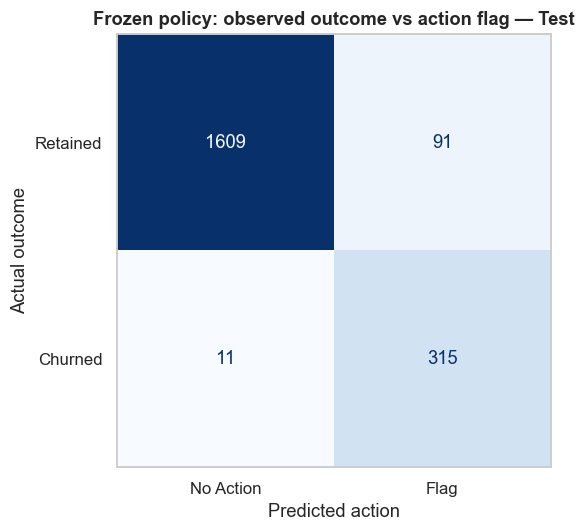

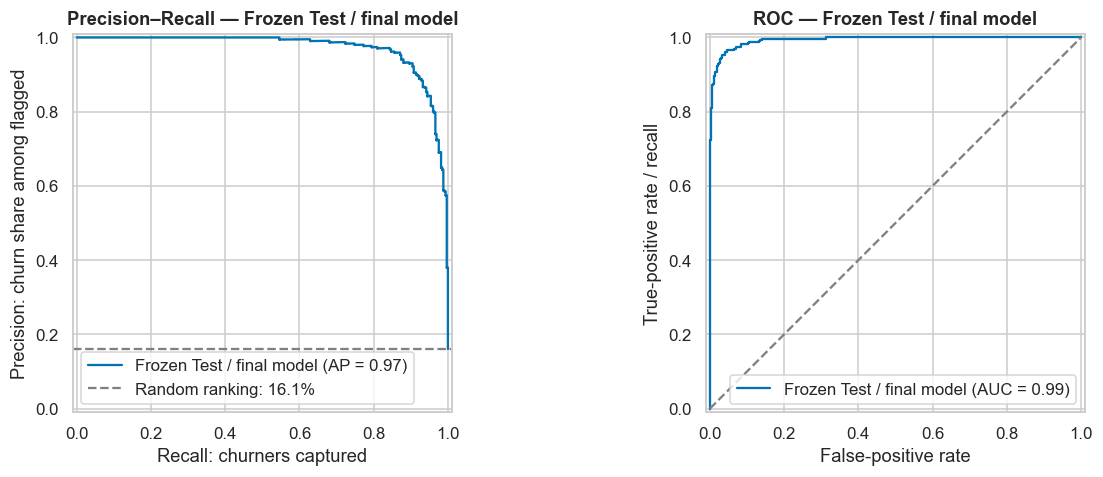

**Result:** TP=315, FP=91, FN=11, TN=1609. Illustrative test loss = 146 units. **Interpretation:** 315 observed churners were identified, but the number who could be retained by contact remains unknown.

In [16]:
# SINGLE full test scoring pass. All subsequent evaluations reuse these fixed arrays.
test_probability = churn_probability(final_model, X_test)
test_flag = (test_probability >= frozen_threshold).astype(int)
test_decision = decision_row(y_test, test_probability, frozen_threshold)
test_metric_values = {
    "Average Precision": average_precision_score(y_test, test_probability),
    "ROC-AUC": roc_auc_score(y_test, test_probability),
    "Accuracy": accuracy_score(y_test, test_flag),
    "Balanced Accuracy": balanced_accuracy_score(y_test, test_flag),
    "Precision": precision_score(y_test, test_flag, zero_division=0),
    "Recall": recall_score(y_test, test_flag, zero_division=0),
    "F1": f1_score(y_test, test_flag, zero_division=0),
    "Brier Score": brier_score_loss(y_test, test_probability),
    "Illustrative decision loss": test_decision["decision_loss"],
    "Frozen threshold": frozen_threshold,
    **{key: test_decision[key] for key in ["TP", "FP", "FN", "TN"]},
}
final_metrics = pd.DataFrame({"metric": list(test_metric_values), "value": list(test_metric_values.values())})
display(final_metrics)
test_predictions = pd.DataFrame({"actual_churn": y_test.to_numpy(), "predicted_churn_probability": test_probability, "frozen_action_flag": test_flag})
assert len(test_predictions) == len(y_test)
assert set(test_predictions.columns) == {"actual_churn", "predicted_churn_probability", "frozen_action_flag"}
test_predictions.to_csv(OUTPUT_DIR / "test_predictions.csv", index=False)
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix(y_test, test_flag, labels=[0, 1]), display_labels=["Retained", "Churned"]).plot(ax=ax, colorbar=False, cmap="Blues", values_format="d")
ax.grid(False)
ax.set_xticklabels(["No Action", "Flag"])
ax.set(title="Frozen policy: observed outcome vs action flag — Test", xlabel="Predicted action", ylabel="Actual outcome")
save_figure("test_confusion_matrix")
ranking_figures(y_test, test_probability, "Frozen Test / final model", "test_ranking")
report(f"**Result:** TP={test_decision['TP']}, FP={test_decision['FP']}, FN={test_decision['FN']}, TN={test_decision['TN']}. Illustrative test loss = {test_decision['decision_loss']} units. **Interpretation:** {test_decision['TP']} observed churners were identified, but the number who could be retained by contact remains unknown.")

### Bootstrap uncertainty — enhancement beyond the lecture
**Question.** How uncertain are the final sample metrics? **Method.** Resample held-out customers with replacement 500 times using seed 42 and fixed predictions/threshold; report percentile 95% intervals for AP, ROC-AUC, precision and recall. Skip a replicate only if it lacks both outcome classes.
**Interpretation.** These are conditional intervals for this fitted model and sampling cohort; they do not include model-training, threshold-selection, temporal drift or dataset-selection uncertainty. Reusing frozen predictions for uncertainty estimates does not retune the test policy. Future longitudinal data would need clustered/time-aware uncertainty methods.

In [17]:
bootstrap_random = np.random.default_rng(RANDOM_STATE)
actual_test = y_test.to_numpy()
bootstrap_rows = []
for _ in range(BOOTSTRAP_REPEATS):
    positions = bootstrap_random.integers(0, len(actual_test), size=len(actual_test))
    actual = actual_test[positions]
    if np.unique(actual).size < 2:
        continue
    probability, flag = test_probability[positions], test_flag[positions]
    bootstrap_rows.append({
        "Average Precision": average_precision_score(actual, probability),
        "ROC-AUC": roc_auc_score(actual, probability),
        "Recall": recall_score(actual, flag, zero_division=0),
        "Precision": precision_score(actual, flag, zero_division=0),
    })
assert len(bootstrap_rows) >= int(0.95*BOOTSTRAP_REPEATS), "Too many degenerate bootstrap samples."
bootstrap_intervals = pd.DataFrame(bootstrap_rows).quantile([0.025, 0.975]).T.rename(columns={0.025: "ci_95_low", 0.975: "ci_95_high"})
bootstrap_intervals.index.name = "metric"
display(bootstrap_intervals)
final_metrics = final_metrics.merge(bootstrap_intervals.reset_index(), on="metric", how="left")
final_metrics.to_csv(OUTPUT_DIR / "final_metrics.csv", index=False)
print("Valid bootstrap replicates:", len(bootstrap_rows))

,ci_95_low,ci_95_high
metric,,
Average Precision,0.959576,0.981384
ROC-AUC,0.989694,0.995728
Recall,0.945563,0.985299
Precision,0.740321,0.812595


Valid bootstrap replicates: 500


## 12. Probability calibration — Are risk scores on the right scale?
**Question.** Do customers receiving similar scores have similar observed churn rates?
**Method.** Evaluate frozen test scores using Brier score $N^{-1}\sum_i(p_i-y_i)^2$ and quantile-bin reliability. Above the diagonal means observed churn exceeds predicted risk (underprediction); below means overprediction.
**Result / interpretation.** Read the reliability points with their bin counts. Brier score mixes calibration and discrimination; it is not a pure calibration test. Compare against a constant probability estimated from Train, not a test-fitted baseline.
**Business implication.** Unreliable probabilities can distort economic decisions even when ranking is strong.
**Limitation.** This is evaluation only. No recalibrator is fit on Test. Future Platt/sigmoid or isotonic calibration must use training/validation data with a fresh independent holdout and a newly selected threshold. [sklearn calibration guide](https://scikit-learn.org/stable/modules/calibration.html).

,n,mean_predicted,observed_churn,observed_minus_predicted
bin,,,,
"(-0.000794, 0.000843]",203,0.000574,0.000000,-0.000574
"(0.000843, 0.00132]",203,0.001069,0.000000,-0.001069
"(0.00132, 0.00197]",202,0.001618,0.000000,-0.001618
"(0.00197, 0.00321]",203,0.002519,0.000000,-0.002519
"(0.00321, 0.00537]",202,0.004183,0.000000,-0.004183
"(0.00537, 0.0108]",203,0.007597,0.004926,-0.002671
"(0.0108, 0.039]",202,0.020720,0.000000,-0.020720
"(0.039, 0.274]",203,0.107423,0.049261,-0.058162
"(0.274, 0.968]",202,0.701634,0.559406,-0.142228


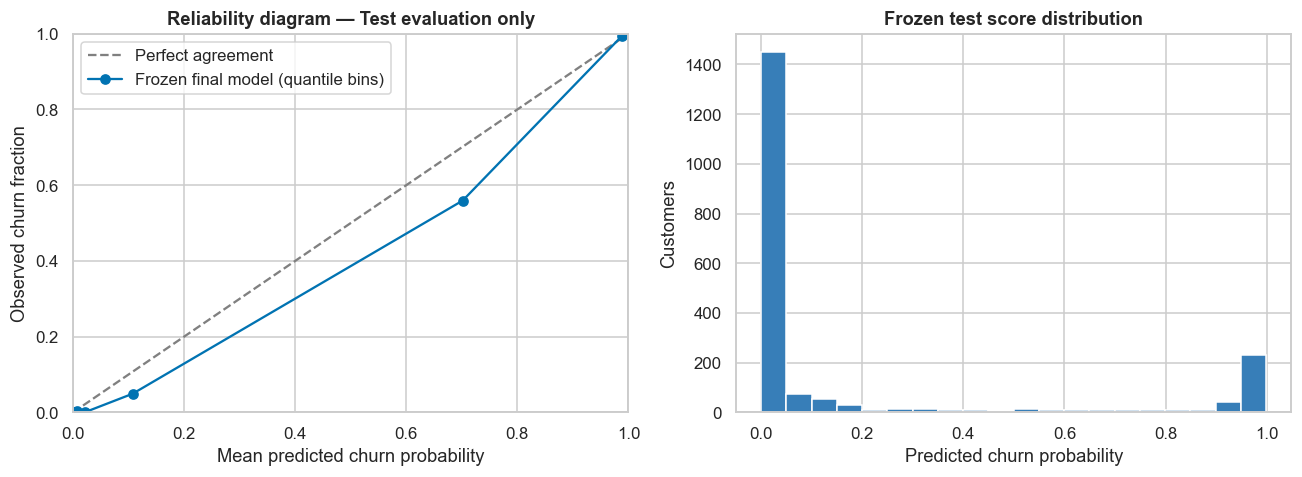

**Result:** Brier = 0.0244; Train-prevalence constant baseline = 0.1350. Mean predicted risk = 18.36%; observed Test churn = 16.09%. The model overpredicts mean observed churn by 2.27 percentage points in aggregate; local bin discrepancies can differ in direction.

In [18]:
observed_fraction, mean_predicted = calibration_curve(y_test, test_probability, n_bins=10, strategy="quantile")
calibration_records = pd.DataFrame({"actual": actual_test, "probability": test_probability})
calibration_records["bin"] = pd.qcut(calibration_records["probability"], q=10, duplicates="drop")
calibration_table = calibration_records.groupby("bin", observed=True).agg(n=("actual", "size"), mean_predicted=("probability", "mean"), observed_churn=("actual", "mean"))
calibration_table["observed_minus_predicted"] = calibration_table["observed_churn"]-calibration_table["mean_predicted"]
display(calibration_table)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot([0, 1], [0, 1], "--", color="gray", label="Perfect agreement")
axes[0].plot(mean_predicted, observed_fraction, "o-", label="Frozen final model (quantile bins)")
axes[0].set(title="Reliability diagram — Test evaluation only", xlabel="Mean predicted churn probability", ylabel="Observed churn fraction", xlim=(0, 1), ylim=(0, 1))
axes[0].legend()
axes[1].hist(test_probability, bins=20, color="#377eb8")
axes[1].set(title="Frozen test score distribution", xlabel="Predicted churn probability", ylabel="Customers")
save_figure("test_calibration")
train_constant_brier = brier_score_loss(y_test, np.repeat(y_train.mean(), len(y_test)))
mean_calibration_gap = float(actual_test.mean()-test_probability.mean())
calibration_direction = "underpredicts mean observed churn" if mean_calibration_gap > 0 else "overpredicts mean observed churn" if mean_calibration_gap < 0 else "matches mean observed churn"
report(f"**Result:** Brier = {test_metric_values['Brier Score']:.4f}; Train-prevalence constant baseline = {train_constant_brier:.4f}. Mean predicted risk = {test_probability.mean():.2%}; observed Test churn = {actual_test.mean():.2%}. The model {calibration_direction} by {abs(mean_calibration_gap)*100:.2f} percentage points in aggregate; local bin discrepancies can differ in direction.")

## 13. SHAP explainability — What drives the fitted forest?
**Question.** Which inputs contribute to this model's churn scores?
**Method.** SHAP treats features as players in a cooperative prediction game:
$$f(x)=\phi_0+\sum_j\phi_j.$$
The Shapley concept averages a feature's marginal contribution across coalition positions:
$$\phi_j=\sum_{S\subseteq F\setminus\{j\}}\frac{|S|!(|F|-|S|-1)!}{|F|!}\big[v(S\cup\{j\})-v(S)\big].$$
$\phi_0$ is the model reference output; positive $\phi_j$ raises modeled churn risk relative to that reference, negative lowers it.

Use the already fitted course-aligned forest and its frozen ColumnTransformer. If a challenger was selected for final prediction, SHAP explains the separate forest, not the challenger: it is a pedagogical reference-model analysis and does not evaluate a second test policy. Explain at most 200 randomly sampled test customers for global summaries; select one local case solely by the highest frozen **forest** predicted probability. Labels never select the explanation sample or local case. The local case is explained separately if not in the random sample, keeping the global sample unbiased by deliberate high-risk inclusion.

**Version handling.** TreeSHAP may return a class-array list, a three-dimensional ndarray, or an Explanation. The resolver tests explicit class axes against `classes_` and verifies reconstructed Churn=1 probabilities using frozen test scores. An unsupported shape fails clearly rather than silently explaining the wrong class. An interventional TreeSHAP fallback uses a background from Train only if path-dependent TreeSHAP is incompatible, and reports the changed reference. [TreeExplainer documentation](https://shap.readthedocs.io/en/latest/generated/shap.TreeExplainer.html).

**Interpretation / business implication.** Explanations help audit model reasoning and form intervention hypotheses.
**Limitation.** SHAP describes fitted-model behavior, not causal influence or intervention value.

In [19]:
fitted_preprocessor = course_forest_pipeline.named_steps["preprocess"]
forest = course_forest_pipeline.named_steps["model"]
forest_explanation_probability = test_probability if final_model_name == course_forest_name else churn_probability(course_forest_pipeline, X_test)
report(f"**SHAP model:** {course_forest_name}. **Final predictive model:** {final_model_name}. " + ("These are the same model." if final_model_name == course_forest_name else "These are different models. Forest scores are used only for explanation; no forest test outcome metrics or threshold comparison are computed."))
assert isinstance(forest, RandomForestClassifier)
transformed_names = np.asarray(fitted_preprocessor.get_feature_names_out(), dtype=str)
positive_class = int(np.flatnonzero(forest.classes_ == 1)[0])
number_of_classes = len(forest.classes_)
shap_random = np.random.default_rng(RANDOM_STATE)
global_positions = np.sort(shap_random.choice(len(X_test), size=min(SHAP_SAMPLE_SIZE, len(X_test)), replace=False))
local_position = int(np.argmax(forest_explanation_probability))  # Label is not accessed.
explain_positions = np.unique(np.r_[global_positions, local_position])
explain_frame = course_forest_pipeline.named_steps["features"].transform(X_test.iloc[explain_positions])
transformed_explain = np.asarray(fitted_preprocessor.transform(explain_frame), dtype=float)
assert transformed_explain.shape[1] == len(transformed_names)
assert np.isfinite(transformed_explain).all()
expected_probabilities = forest_explanation_probability[explain_positions]

def resolve_positive_shap(output, expected_value, reference_probabilities):
    values = output.values if hasattr(output, "base_values") else output
    base = output.base_values if hasattr(output, "base_values") else expected_value
    n, p = transformed_explain.shape
    value_candidates = []
    if isinstance(values, list):
        if len(values) == number_of_classes:
            value_candidates.append(np.asarray(values[positive_class]))
    else:
        values = np.asarray(values)
        if values.shape == (n, p):
            value_candidates.append(values)
        if values.ndim == 3:
            if values.shape == (n, p, number_of_classes):
                value_candidates.append(values[:, :, positive_class])
            if values.shape == (number_of_classes, n, p):
                value_candidates.append(values[positive_class])
            if values.shape == (n, number_of_classes, p):
                value_candidates.append(values[:, positive_class, :])
    base = np.asarray(base)
    base_candidates = []
    if base.ndim == 0:
        base_candidates.append(np.repeat(float(base), n))
    elif base.shape == (number_of_classes,):
        base_candidates.append(np.repeat(base[positive_class], n))
    elif base.shape == (n, number_of_classes):
        base_candidates.append(base[:, positive_class])
    elif base.shape == (number_of_classes, n):
        base_candidates.append(base[positive_class])
    elif base.shape == (n,):
        base_candidates.append(base)
    elif base.shape == (n, 1):
        base_candidates.append(base[:, 0])
    for contribution in value_candidates:
        for baseline in base_candidates:
            if contribution.shape == (n, p) and np.isfinite(contribution).all():
                reconstructed = baseline + contribution.sum(axis=1)
                if np.allclose(reconstructed, reference_probabilities, atol=2e-5, rtol=2e-5):
                    return contribution, baseline
    raise ValueError(f"Cannot validate Churn=1 SHAP axes/additivity. Values shape={np.shape(values)}, base shape={base.shape}.")

def compute_tree_shap(explainer):
    if hasattr(explainer, "__call__"):
        try:
            result = explainer(transformed_explain, check_additivity=True)
        except TypeError:
            result = explainer.shap_values(transformed_explain, check_additivity=True)
    else:
        result = explainer.shap_values(transformed_explain, check_additivity=True)
    return resolve_positive_shap(result, explainer.expected_value, expected_probabilities)

try:
    tree_explainer = shap.TreeExplainer(forest, model_output="raw", feature_perturbation="tree_path_dependent")
    shap_values_positive, shap_baseline = compute_tree_shap(tree_explainer)
    shap_reference_method = "tree_path_dependent (tree path training counts)"
except Exception as path_error:
    # Narrowly scoped compatibility fallback; any second failure remains a clear error.
    print(f"Path-dependent TreeSHAP incompatible: {type(path_error).__name__}: {str(path_error)[:180]}")
    background_frame = X_train.sample(n=min(100, len(X_train)), random_state=RANDOM_STATE)
    background_matrix = fitted_preprocessor.transform(course_forest_pipeline.named_steps["features"].transform(background_frame))
    tree_explainer = shap.TreeExplainer(forest, data=background_matrix, model_output="probability", feature_perturbation="interventional")
    shap_values_positive, shap_baseline = compute_tree_shap(tree_explainer)
    shap_reference_method = "interventional TreeSHAP (100 or fewer Train background rows); not a causal intervention estimate"

shap_additivity_error = float(np.max(np.abs(shap_baseline + shap_values_positive.sum(axis=1) - expected_probabilities)))
assert np.allclose(shap_baseline + shap_values_positive.sum(axis=1), expected_probabilities, atol=2e-5, rtol=2e-5)
global_explain_rows = np.flatnonzero(np.isin(explain_positions, global_positions))
local_explain_row = int(np.flatnonzero(explain_positions == local_position)[0])
global_values = shap_values_positive[global_explain_rows]
global_matrix = transformed_explain[global_explain_rows]
print("SHAP reference:", shap_reference_method)
print("Positive class:", forest.classes_[positive_class], "| max additivity error:", shap_additivity_error)

**SHAP model:** Random Forest tuned. **Final predictive model:** LightGBM benchmark. These are different models. Forest scores are used only for explanation; no forest test outcome metrics or threshold comparison are computed.

SHAP reference: tree_path_dependent (tree path training counts)
Positive class: 1 | max additivity error: 1.9317880628477724e-14


,transformed_feature,source_feature,mean_absolute_shap
11,numeric__Total_Trans_Ct,Total_Trans_Ct,0.147118
10,numeric__Total_Trans_Amt,Total_Trans_Amt,0.091323
7,numeric__Total_Revolving_Bal,Total_Revolving_Bal,0.062069
12,numeric__Total_Ct_Chng_Q4_Q1,Total_Ct_Chng_Q4_Q1,0.047645
14,numeric__average_ticket,average_ticket,0.043360
13,numeric__Avg_Utilization_Ratio,Avg_Utilization_Ratio,0.039959
3,numeric__Total_Relationship_Count,Total_Relationship_Count,0.030996
15,numeric__contact_ratio,contact_ratio,0.029243
9,numeric__Total_Amt_Chng_Q4_Q1,Total_Amt_Chng_Q4_Q1,0.019938
4,numeric__Months_Inactive_12_mon,Months_Inactive_12_mon,0.018477


,source_feature,mean_absolute_grouped_shap
11,Total_Trans_Ct,0.147118
10,Total_Trans_Amt,0.091323
7,Total_Revolving_Bal,0.062069
12,Total_Ct_Chng_Q4_Q1,0.047645
14,average_ticket,0.043360
13,Avg_Utilization_Ratio,0.039959
3,Total_Relationship_Count,0.030996
15,contact_ratio,0.029243
9,Total_Amt_Chng_Q4_Q1,0.019938
4,Months_Inactive_12_mon,0.018477


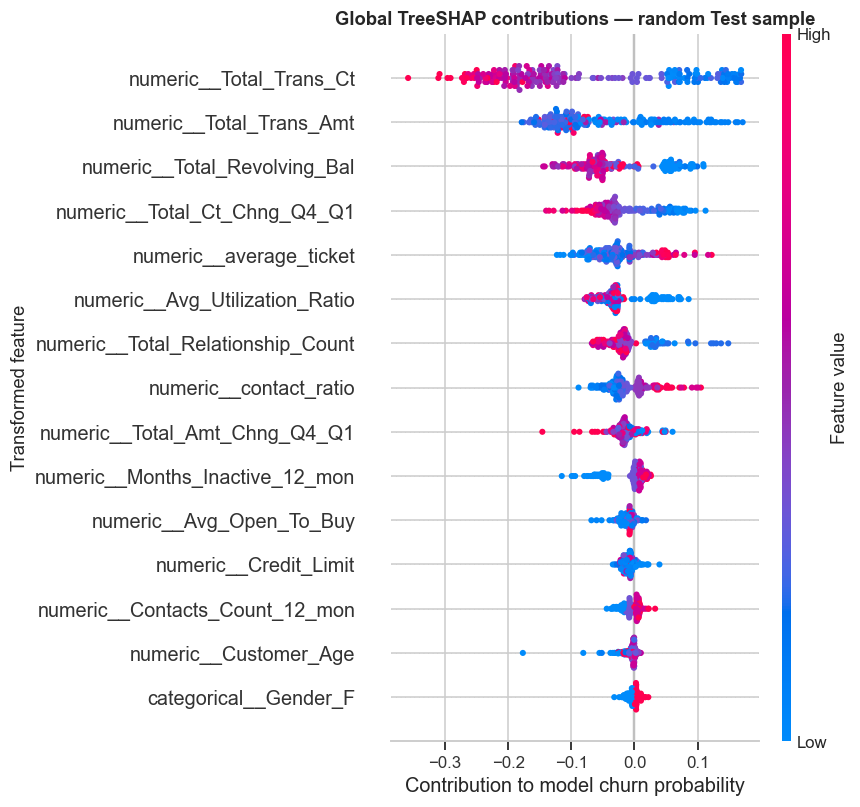

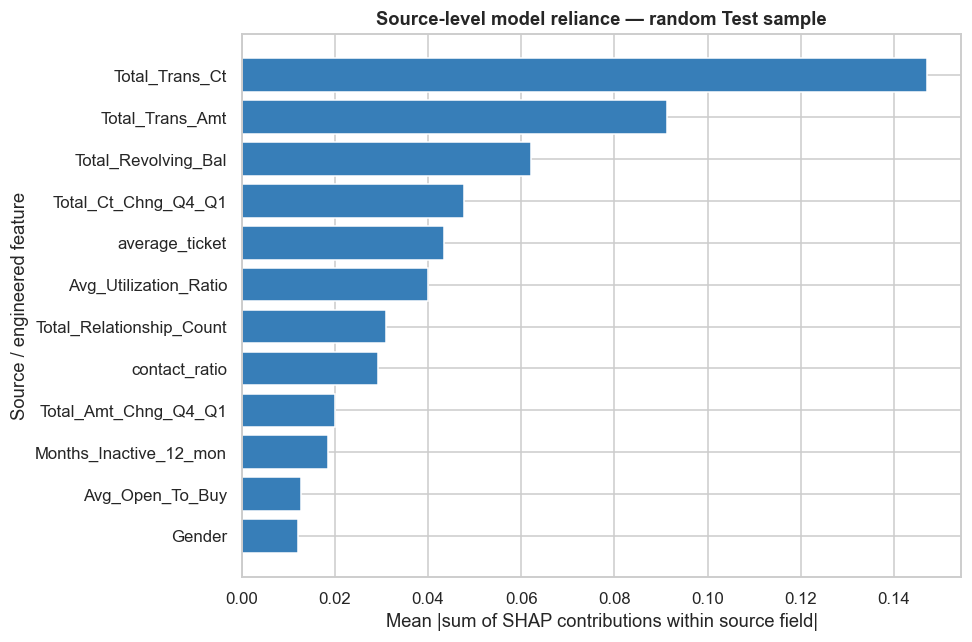

**Computed leading source attributions:** Total_Trans_Ct, Total_Trans_Amt, Total_Revolving_Bal, Total_Ct_Chng_Q4_Q1, average_ticket. **Interpretation:** Mean |SHAP| describes how strongly this fitted forest relies on an input. It is not causal importance, intervention value or profit ranking. Source aggregation sums signed dummy contributions per customer before taking absolute means; cancellation is possible and this is not a newly fitted grouped Shapley game.

In [20]:
# Map transformed columns to source fields using fitted encoder metadata, never underscore splitting.
fitted_encoder = fitted_preprocessor.named_transformers_["categorical"].named_steps["encoder"]
source_names = list(numeric_columns)
for field, levels in zip(categorical_columns, fitted_encoder.categories_):
    source_names.extend([field] * len(levels))
assert len(source_names) == len(transformed_names), "Transformed-to-source mapping mismatch."
shap_global_importance = pd.DataFrame({
    "transformed_feature": transformed_names, "source_feature": source_names,
    "mean_absolute_shap": np.abs(global_values).mean(axis=0),
}).sort_values("mean_absolute_shap", ascending=False)
shap_global_importance.to_csv(OUTPUT_DIR / "shap_global_importance.csv", index=False)
display(shap_global_importance.head(15))
grouped_values = pd.DataFrame(shap_values_positive, columns=source_names).T.groupby(level=0, sort=False).sum().T
source_importance = pd.DataFrame({
    "source_feature": grouped_values.columns,
    "mean_absolute_grouped_shap": np.abs(grouped_values.iloc[global_explain_rows]).mean(axis=0).to_numpy(),
}).sort_values("mean_absolute_grouped_shap", ascending=False)
source_importance.to_csv(OUTPUT_DIR / "shap_source_importance.csv", index=False)
display(source_importance.head(12))
summary_options = {"rng": RANDOM_STATE} if "rng" in inspect.signature(shap.summary_plot).parameters else {}
shap.summary_plot(global_values, global_matrix, feature_names=transformed_names, max_display=15, show=False, **summary_options)
plt.title("Global TreeSHAP contributions — random Test sample")
plt.xlabel("Contribution to model churn probability")
plt.ylabel("Transformed feature")
save_figure("shap_beeswarm")
top_sources = source_importance.head(12).iloc[::-1]
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top_sources["source_feature"], top_sources["mean_absolute_grouped_shap"], color="#377eb8")
ax.set(title="Source-level model reliance — random Test sample", xlabel="Mean |sum of SHAP contributions within source field|", ylabel="Source / engineered feature")
save_figure("shap_source_importance")
top_shap_drivers = source_importance.head(5)["source_feature"].tolist()
report(f"**Computed leading source attributions:** {', '.join(top_shap_drivers)}. **Interpretation:** Mean |SHAP| describes how strongly this fitted forest relies on an input. It is not causal importance, intervention value or profit ranking. Source aggregation sums signed dummy contributions per customer before taking absolute means; cancellation is possible and this is not a newly fitted grouped Shapley game.")

### Nonlinear transaction-count pattern
**Question.** How does the model's transaction-count contribution vary across customers?
**Method.** Plot original transaction counts against grouped/source SHAP probability contributions. **Interpretation.** Crossing zero changes whether the feature raises or lowers this model's score relative to its reference. Bends suggest candidate behavioral triggers; vertical spread can reflect interactions. **Business implication.** Use these shapes to frame prospective tests. **Limitation.** Sparse tails, correlated inputs and model/reference choice can change the pattern. A visual bend is not a production threshold without independent stability testing.

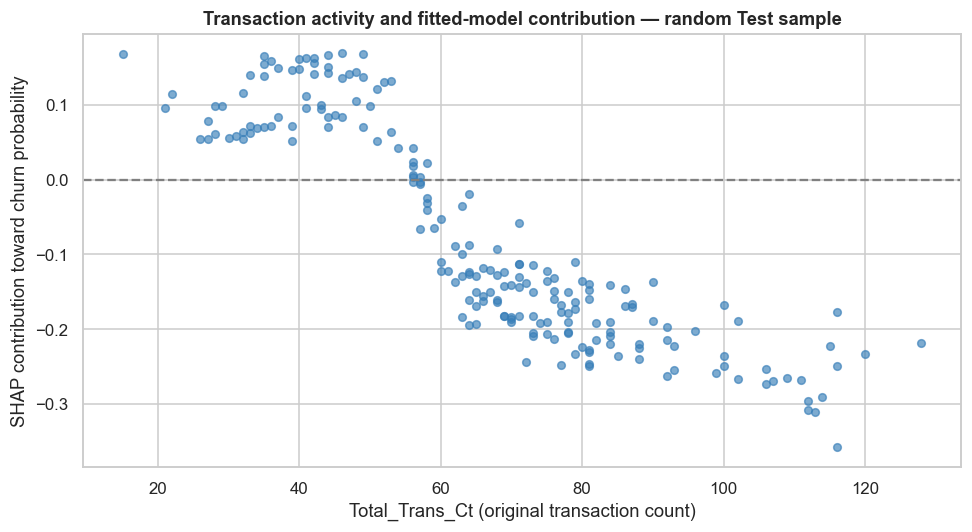

Sample contributions above zero: 68 below zero: 132


In [21]:
fig, ax = plt.subplots(figsize=(9, 5))
count_values = X_test.iloc[global_positions]["Total_Trans_Ct"].to_numpy()
count_contributions = grouped_values.iloc[global_explain_rows]["Total_Trans_Ct"].to_numpy()
ax.scatter(count_values, count_contributions, alpha=0.65, s=25, color="#377eb8")
ax.axhline(0, linestyle="--", color="gray")
ax.set(title="Transaction activity and fitted-model contribution — random Test sample", xlabel="Total_Trans_Ct (original transaction count)", ylabel="SHAP contribution toward churn probability")
save_figure("shap_transaction_dependence")
print("Sample contributions above zero:", int((count_contributions > 0).sum()), "below zero:", int((count_contributions < 0).sum()))

### Local high-risk customer — selected without the observed label
**Question.** Why did the forest assign its highest test risk score to this customer?
**Method.** Select by `argmax(forest_explanation_probability)` only; show original predictors, model reference, positive/negative contributions and waterfall. CLIENTNUM and the observed outcome are omitted. If a challenger is the final model, this local case still describes only the course forest's highest-scored customer.
**Interpretation.** This is evidence used by the fitted model. **Business implication.** A reviewer can check account context before considering an intervention. **Limitation.** These features did not thereby cause churn, and the selected customer is not representative of the whole test sample.

,original_value
Customer_Age,42
Gender,F
Dependent_count,3
Education_Level,High School
Marital_Status,Single
Income_Category,Less than $40K
Card_Category,Blue
Months_on_book,36
Total_Relationship_Count,2
Months_Inactive_12_mon,3


,engineered_value
average_ticket,58.690476
contact_ratio,1.500000


,transformed_feature,SHAP_contribution
11,numeric__Total_Trans_Ct,0.159158
10,numeric__Total_Trans_Amt,0.116532
12,numeric__Total_Ct_Chng_Q4_Q1,0.060836
7,numeric__Total_Revolving_Bal,0.055091
15,numeric__contact_ratio,0.034208
13,numeric__Avg_Utilization_Ratio,0.033892


,transformed_feature,SHAP_contribution
6,numeric__Credit_Limit,-0.007323
8,numeric__Avg_Open_To_Buy,-0.007299
14,numeric__average_ticket,-0.006049
9,numeric__Total_Amt_Chng_Q4_Q1,-0.004227
21,categorical__Education_Level_High School,-0.004108
28,categorical__Marital_Status_Unknown,-0.000218


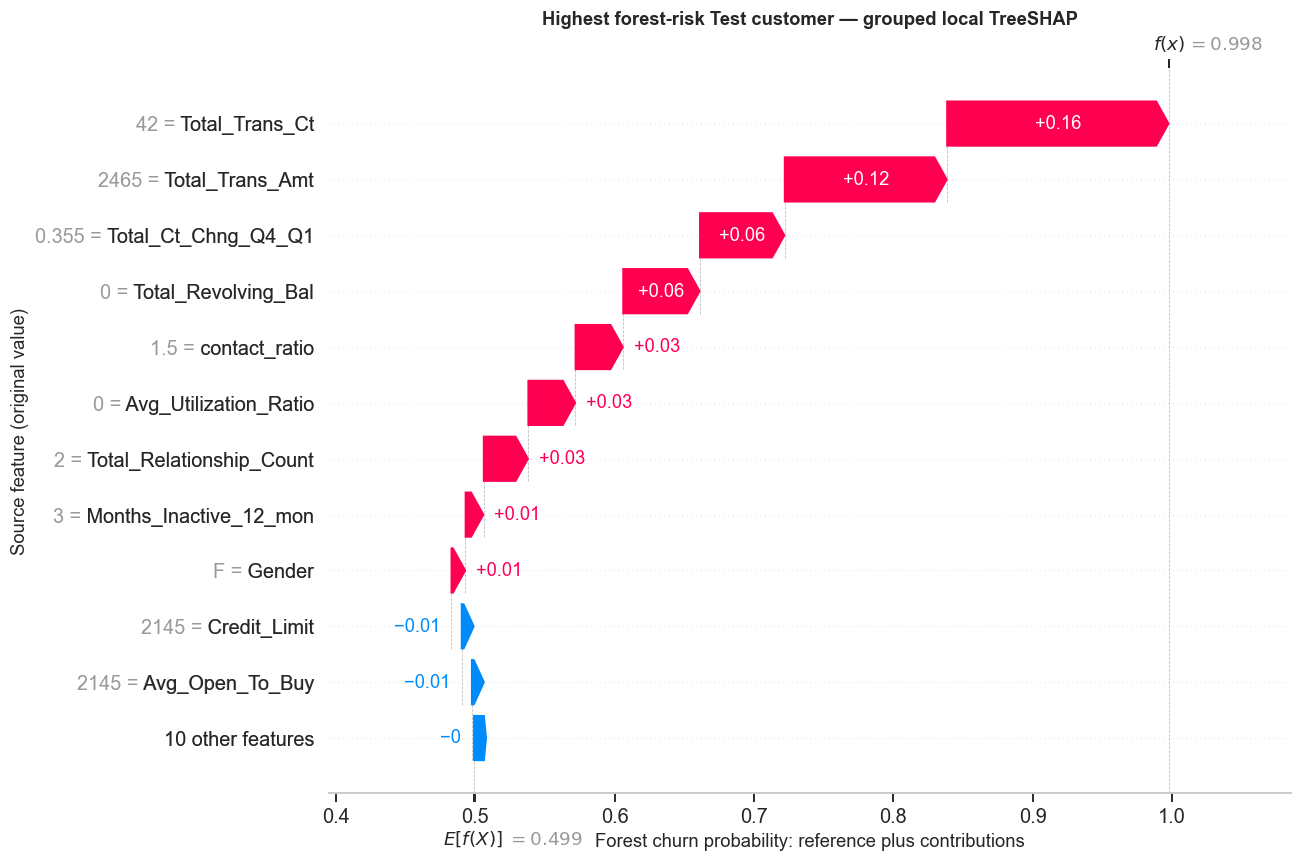

**Local reconstruction:** reference 0.4989 + total contribution +0.4987 = predicted churn probability 0.9976. Largest positive model evidence: numeric__Total_Trans_Ct, numeric__Total_Trans_Amt, numeric__Total_Ct_Chng_Q4_Q1. Largest negative model evidence: numeric__Credit_Limit, numeric__Avg_Open_To_Buy, numeric__average_ticket. No observed label was used to select this case.

In [22]:
local_values = shap_values_positive[local_explain_row]
local_base = float(shap_baseline[local_explain_row])
local_probability = float(forest_explanation_probability[local_position])
display(X_test.iloc[local_position].rename("original_value").to_frame())
display(add_snapshot_features(X_test.iloc[[local_position]])[["average_ticket", "contact_ratio"]].T.rename(columns={X_test.index[local_position]: "engineered_value"}))
local_table = pd.DataFrame({"transformed_feature": transformed_names, "SHAP_contribution": local_values})
positive_local = local_table[local_table["SHAP_contribution"] > 0].nlargest(6, "SHAP_contribution")
negative_local = local_table[local_table["SHAP_contribution"] < 0].nsmallest(6, "SHAP_contribution")
display(positive_local)
display(negative_local)
if hasattr(shap, "Explanation") and hasattr(shap.plots, "waterfall"):
    local_grouped = grouped_values.iloc[local_explain_row]
    assert np.isclose(local_base + local_grouped.sum(), local_probability, atol=2e-5)
    local_explanation = shap.Explanation(values=local_grouped.to_numpy(), base_values=local_base,
                                         data=explain_frame.iloc[local_explain_row][local_grouped.index].to_numpy(),
                                         feature_names=local_grouped.index.tolist())
    shap.plots.waterfall(local_explanation, max_display=12, show=False)
    waterfall_figure = plt.gcf()
    waterfall_figure.set_size_inches(12, 8)
    for waterfall_axis in waterfall_figure.axes:
        waterfall_axis.grid(False)
    waterfall_figure.axes[0].set(xlabel="Forest churn probability: reference plus contributions",
                                 ylabel="Source feature (original value)")
    plt.title("Highest forest-risk Test customer — grouped local TreeSHAP")
else:
    # A true additive waterfall for older plot APIs, including a residual group.
    order = np.argsort(np.abs(local_values))[::-1][:10]
    waterfall_values = list(local_values[order]) + [float(local_values.sum()-local_values[order].sum())]
    waterfall_labels = list(transformed_names[order]) + ["Other features"]
    fig, ax = plt.subplots(figsize=(10, 7))
    current = local_base
    for position, contribution in enumerate(waterfall_values):
        ax.barh(position, abs(contribution), left=min(current, current+contribution), color="#e17c05" if contribution > 0 else "#377eb8")
        current += contribution
    ax.set_yticks(range(len(waterfall_labels)), waterfall_labels)
    ax.axvline(local_base, linestyle="--", label="Reference")
    ax.axvline(local_probability, color="black", label="Prediction")
    ax.set(title="Highest predicted-risk Test customer — additive SHAP waterfall", xlabel="Model churn probability", ylabel="Transformed feature")
    ax.legend()
save_figure("shap_local_waterfall")
report(f"**Local reconstruction:** reference {local_base:.4f} + total contribution {local_values.sum():+.4f} = predicted churn probability {local_probability:.4f}. Largest positive model evidence: {', '.join(positive_local['transformed_feature'].head(3)) or 'none'}. Largest negative model evidence: {', '.join(negative_local['transformed_feature'].head(3)) or 'none'}. No observed label was used to select this case.")

### Explanation boundaries
1. Correlated inputs can share SHAP credit.
2. Derived ratios overlap with their parent variables.
3. Rankings depend on the fitted model and reference/background definition.
4. Tree-path attribution is not a causal effect.
5. Positive SHAP increases **model risk**, not estimated treatment effectiveness.
6. The most important SHAP feature need not offer the highest profit if changed.

| Evidence | Supported interpretation |
|---|---|
| High predicted risk | Prioritize review |
| Positive SHAP | Raises this model's prediction |
| Mean absolute SHAP | Model reliance |
| Randomized treatment lift | Action effectiveness under the experiment's assumptions |

### Subgroup model-risk diagnostics — enhancement beyond the lecture
**Question.** Is performance obviously unstable across sufficiently large groups?
**Method.** Reuse the frozen test arrays for Gender, Card_Category, Income_Category and Education_Level. Report n, positives, flags, prevalence, average risk, Brier score, precision and recall. Display precision/recall only when a group has at least 100 customers, 20 churners, 20 retained customers and 20 flags.
**Interpretation.** Different prevalence and sample sizes can change metrics without establishing discrimination or causal mechanisms. **Business implication.** Flag large disparities for a prospective model-risk review. **Limitation.** Small groups remain visible with metrics suppressed; these exploratory audits have no multiplicity adjustment, no protected-class causal interpretation and do not trigger test-driven model changes.

In [23]:
subgroup_rows = []
for field in ["Gender", "Card_Category", "Income_Category", "Education_Level"]:
    field_values = X_test[field].fillna("<Missing>").astype(str).to_numpy()
    for group in sorted(np.unique(field_values)):
        mask = field_values == group
        actual, probability, flag = actual_test[mask], test_probability[mask], test_flag[mask]
        enough = len(actual) >= MIN_AUDIT_N and actual.sum() >= MIN_AUDIT_POSITIVES and (len(actual)-actual.sum()) >= MIN_AUDIT_POSITIVES and flag.sum() >= MIN_AUDIT_POSITIVES
        subgroup_rows.append({
            "field": field, "group": group, "n": len(actual), "churn_n": int(actual.sum()), "flagged_n": int(flag.sum()),
            "churn_prevalence": actual.mean(), "average_predicted_risk": probability.mean(),
            "Brier_score": brier_score_loss(actual, probability),
            "recall": recall_score(actual, flag, zero_division=0) if enough else np.nan,
            "precision": precision_score(actual, flag, zero_division=0) if enough else np.nan,
            "status": "descriptive comparison eligible" if enough else "small group or insufficient outcome/flag counts; P/R suppressed",
        })
subgroup_metrics = pd.DataFrame(subgroup_rows)
display(subgroup_metrics)
subgroup_metrics.to_csv(OUTPUT_DIR / "subgroup_metrics.csv", index=False)
eligible_audit = subgroup_metrics[subgroup_metrics["status"] == "descriptive comparison eligible"]
if len(eligible_audit):
    report(f"**Descriptive result:** Among {len(eligible_audit)} eligible subgroup slices, recall ranges from {eligible_audit['recall'].min():.1%} to {eligible_audit['recall'].max():.1%}. These overlapping, exploratory slices are model-risk signals, not a formal fairness verdict; no policy is retuned on this audit.")
else:
    report("No subgroup met the predeclared metric-support criteria; collect more observations before comparing subgroup recall/precision.")

,field,group,n,churn_n,flagged_n,churn_prevalence,average_predicted_risk,Brier_score,recall,precision,status
0,Gender,F,1039,183,212,0.176131,0.191204,0.017153,0.983607,0.849057,descriptive comparison eligible
1,Gender,M,987,143,194,0.144883,0.175670,0.031936,0.944056,0.695876,descriptive comparison eligible
2,Card_Category,Blue,1878,306,380,0.162939,0.184683,0.024948,0.964052,0.776316,descriptive comparison eligible
3,Card_Category,Gold,20,1,2,0.050000,0.092374,0.019908,NaN,NaN,small group or insufficient outcome/flag count...
4,Card_Category,Platinum,4,0,0,0.000000,0.017672,0.000861,NaN,NaN,small group or insufficient outcome/flag count...
5,Card_Category,Silver,124,19,24,0.153226,0.187870,0.016847,NaN,NaN,small group or insufficient outcome/flag count...
6,Income_Category,$120K +,160,29,37,0.181250,0.204186,0.021538,0.965517,0.756757,descriptive comparison eligible
7,Income_Category,$40K - $60K,360,65,80,0.180556,0.210662,0.029358,0.969231,0.787500,descriptive comparison eligible
8,Income_Category,$60K - $80K,282,27,50,0.095745,0.137520,0.039136,0.962963,0.520000,descriptive comparison eligible
9,Income_Category,$80K - $120K,323,54,61,0.167183,0.185251,0.025121,0.925926,0.819672,descriptive comparison eligible


**Descriptive result:** Among 14 eligible subgroup slices, recall ranges from 92.6% to 100.0%. These overlapping, exploratory slices are model-risk signals, not a formal fairness verdict; no policy is retuned on this audit.

## 14. Business retention strategy — Convert evidence into testable hypotheses
**Question.** Which observed patterns justify a retention pilot hypothesis?
**Method.** Use actual training EDA and fitted-model reliance. Compare low/high transaction quartiles and, for discrete fields, the lowest/highest adequately sized levels. The table reports the computed directional difference even when it contradicts the expected story.
**Result.** The next cell produces an evidence-linked playbook. **Interpretation.** A high score answers “who may be at risk?” It does not answer “who will stay because we intervene?”
**Business implication.** Verify account eligibility and context before randomized contact.
**Limitation.** The proposed actions are hypotheses. Contact counts do not establish service friction; activity does not establish the effect of reactivation offers.

```text
Risk-ranked eligible cohort
        ↓
Verify customer/account context
        ↓
Choose intervention hypothesis
        ↓
Randomized retention pilot
        ↓
Measure incremental retained value
        ↓
Scale / modify / stop
```

In [24]:
contact_segments = segment_summary(train, "Contacts_Count_12_mon")
playbook_rows = [{
    "pattern": "Transaction activity", "training_evidence": f"Lowest vs highest quartile: {low_activity_rate:.1%} vs {high_activity_rate:.1%}",
    "candidate_hypothesis": "Reactivation / engagement review" if low_activity_rate > high_activity_rate else "Investigate activity mix; expected low-activity direction not supported",
    "limitation": "Association only; engagement intervention effect unknown",
}]
for pattern, table, expected_direction, action in [
    ("Inactivity", inactivity_segments, "higher", "Service / usage check"),
    ("Contact frequency", contact_segments, "higher", "Investigate possible service friction"),
    ("Relationship depth", relationship_segments, "lower", "Relationship needs review"),
]:
    supported = table.loc[table["n"] >= MIN_SEGMENT_N].sort_index()
    if len(supported) >= 2:
        first, last = supported.iloc[0], supported.iloc[-1]
        direction_supported = last["churn_rate"] > first["churn_rate"] if expected_direction == "higher" else first["churn_rate"] > last["churn_rate"]
        evidence = f"Adequate-n levels {supported.index[0]} vs {supported.index[-1]}: {first['churn_rate']:.1%} vs {last['churn_rate']:.1%} churn"
        hypothesis = action if direction_supported else "Expected direction not supported by this endpoint comparison; investigate before proposing a trigger"
    else:
        evidence, hypothesis = "Insufficient adequately sized levels", "Collect evidence before defining an intervention"
    playbook_rows.append({"pattern": pattern, "training_evidence": evidence, "candidate_hypothesis": hypothesis, "limitation": "Observational association; confounding and timing unresolved"})
retention_playbook = pd.DataFrame(playbook_rows)
display(retention_playbook)
retention_playbook.to_csv(OUTPUT_DIR / "retention_hypotheses.csv", index=False)
report(f"**Model cross-check:** Leading SHAP source fields are {', '.join(top_shap_drivers)}. These indicate model reliance only. {ASSOCIATION_NOTE}")

,pattern,training_evidence,candidate_hypothesis,limitation
0,Transaction activity,Lowest vs highest quartile: 37.5% vs 1.3%,Reactivation / engagement review,Association only; engagement intervention effe...
1,Inactivity,Adequate-n levels 1 vs 6: 4.3% vs 15.7% churn,Service / usage check,Observational association; confounding and tim...
2,Contact frequency,Adequate-n levels 0 vs 5: 1.6% vs 32.7% churn,Investigate possible service friction,Observational association; confounding and tim...
3,Relationship depth,Adequate-n levels 1 vs 6: 25.8% vs 11.2% churn,Relationship needs review,Observational association; confounding and tim...


**Model cross-check:** Leading SHAP source fields are Total_Trans_Ct, Total_Trans_Amt, Total_Revolving_Bal, Total_Ct_Chng_Q4_Q1, average_ticket. These indicate model reliance only. Observational training-set associations only. Customer mix, confounding, label timing, and correlated behaviors may explain differences; association does not establish causation.

## 15. Causal / uplift limitations and experiment design — What should we do?
### Survival analysis: not identified from this source
**Question.** When will a customer leave? Survival is $S(t)=P(T>t)$; hazard is the instantaneous event rate among customers still at risk. **Empirical survival is not identified from this snapshot.** `Months_on_book` is not a valid substitute for observed event/censoring time.

To fit Kaplan–Meier, Cox, survival forest or empirical hazard models, obtain a join/start date, event/churn date, censoring date, and covariates known before each interval, with consistent observation origins. No survival model or synthetic survival estimate is fitted here.

### Predictive risk versus causal uplift
**Question.** Who stays because of treatment? Predictive risk is $P(\mathrm{churn}\mid X)$. Define the causal outcome **Y = 1 for retained**, so positive $E[Y(1)-Y(0)\mid X]$ means beneficial retention uplift. This sign convention differs from the classifier's Churn=1 target.

| Conceptual uplift group | Potential retention outcomes |
|---|---|
| Persuadables | Stay only when treated |
| Sure Things | Stay with or without treatment |
| Lost Causes | Leave with or without treatment |
| Sleeping Dogs | Treatment may induce leaving / harm |

The highest-risk customer may be impossible to save. These latent groups cannot be individually observed even in a standard randomized trial because each customer receives only one treatment condition.

A future two-model architecture estimates $p_1(x)=P(\mathrm{stay}\mid X,T=1)$ and $p_0(x)=P(\mathrm{stay}\mid X,T=0)$, then $\mathrm{uplift}(x)=p_1(x)-p_0(x)$. Causal interpretation needs randomized assignment (or justified identification assumptions), overlap, consistent treatment and outcomes, and suitable independent validation. **Causal uplift is NOT identifiable from the available observational snapshot:** there is no randomized treatment/control field or verified post-treatment outcome. No uplift model is fitted here.

### Proposed randomized retention experiment — design, not executed
**Method.** First collect temporally valid features and a defined churn horizon, then prospectively validate a scoring policy. Within a prespecified eligible high-risk cohort, randomly assign a retention intervention versus business as usual. Randomize by customer; use stratification on prespecified risk bands if helpful. Prevent shared-account spillovers or randomize at an appropriate cluster level.

| Preregistered item | Required specification before launch |
|---|---|
| Treatment | Exact channel, message, incentive, delivery schedule; start with one well-defined hypothesis |
| Control | Documented business-as-usual service |
| Primary outcome | Retained at a prespecified horizon H, under a fixed attrition definition |
| Horizon and feature cut-off | Set t0, W and H; only pre-t0 features; wait for outcome maturation |
| Eligibility | Contact permissions, account/customer rules and risk-band policy; fixed before assignment |
| Exclusions | Predetermined legal/operational exclusions; do not exclude post-randomization nonresponders |
| Sample size / power | Choose baseline control retention from valid historical data, minimum detectable lift, alpha and power; account for allocation, clustering and multiplicity; no invented numeric sample size |
| Assignment / analysis | Reproducible random assignment; intention-to-treat analysis, including non-delivery; check allocation balance |
| Stopping | Fixed horizon or preregistered sequential boundaries; avoid unplanned repeated significance peeking |
| Cost measurement | Contact, incentive, service and retained contribution margin; same accounting horizon |
| Guardrails | Complaints, opt-outs, adverse customer outcomes, fairness constraints, data protection |

**Primary evaluation:** retention lift = retention_treatment − retention_control, reported in **percentage points with a confidence interval**. Incremental retained customers for a comparable rollout cohort are estimated lift × eligible customer count, with uncertainty and transport assumptions stated.

**Economic evaluation:** incremental retained margin − contact cost − incentive cost = incremental net value. Estimate treatment-control differences in per-assigned-customer net margin, including unsuccessful contacts and costs incurred without rescue; avoid double-counting costs already netted from margin. Report lift, its interval, incremental retained customers and incremental net margin. Investigate subgroup effects only with adequate power and multiplicity control.

**Interpretation / business implication.** Scale only if randomized evidence and expected incremental net value justify the policy within guardrails. **Limitation.** The current classifier provides none of these causal treatment-effect estimates. No pilot has been executed by this notebook.

## 16. Monitoring and deployment considerations — Does value persist?
**Question.** When should a deployed policy be investigated, recalibrated or paused?
**Method.** Establish a prospectively validated operating range, version features/models/policies, and monitor four areas. Owners and cadence below are proposed roles and practices, not claims about an existing organization.

| Area | Dashboard measures | Proposed review / owner | Response |
|---|---|---|---|
| DATA | Missingness, Unknown/unseen categories, feature drift, scoring coverage | Each scoring batch / data owner | Quarantine schema failures; inspect population shifts |
| MODEL | Precision, recall, AP, calibration, subgroup stability | After labels mature / model owner | Investigate degradation with uncertainty; validate replacement on fresh data |
| BUSINESS | Randomized retention lift, contact rate, retained margin, incremental net value | Mature experiment/cohort / retention and finance owners | Scale, modify or stop using causal and economic evidence |
| OPERATIONS | Scoring latency, campaign capacity, eligibility coverage, fairness/safety review | Batch plus campaign review / operations owner | Throttle to approved capacity; pause unsafe or ineligible contacts |

Concept drift means $P(Y\mid X)$ may change even if the scoring code stays unchanged. PSI, distribution tests and category-frequency shifts can diagnose input changes, but fixed universal cutoffs are not automatic retraining rules. PSI depends on binning; distribution-test significance also depends strongly on sample size. Input drift does not itself prove concept drift. Delayed churn labels require cohort tracking and a common matured horizon; contacted outcomes also reflect the intervention policy.

**Conceptual stop-loss:** pause/reassess treatment if randomized uplift becomes negative, incremental net value becomes negative, fairness/safety constraints fail, or material data/model drift invalidates the approved operating range. Use preregistered uncertainty/sequential rules when judging measured lift; do not mistake a single noisy update for certainty.

**Deployment prerequisites.** Define temporal schema and as-of joins; document source lineage, exclusion rules, target horizon, feature availability and retention policy. Validate on a later cohort; secure inputs and audit access; register model and preprocessing versions; separate customer IDs used operationally from analytical exports. A snapshot classifier with a hypothetical cost threshold is an educational artifact until these gates and a retention experiment are passed.

**Interpretation / business implication.** Monitor prediction quality and actual business value together. **Limitation.** No live dashboard, scoring service or automated retraining is claimed by this notebook.

### Artifact export and execution checks
**Question.** Can the results be reproduced and inspected? **Method.** Verify required CSVs, frozen-policy consistency, leakage exclusions and SHAP additivity; write an environment/source manifest and the cohort split summary. All exported predictions omit CLIENTNUM.
**Result.** The next table lists outputs actually generated by this run. **Limitation.** Runtime assertions verify mechanical contracts; they cannot establish causality, temporal validity or business profitability.

In [25]:
partition_summary.to_csv(OUTPUT_DIR / "partition_summary.csv", index=False)
calibration_table.to_csv(OUTPUT_DIR / "calibration_bins.csv")
required_outputs = ["model_comparison.csv", "validation_threshold_analysis.csv", "test_predictions.csv", "shap_global_importance.csv", "final_metrics.csv"]
assert all((OUTPUT_DIR / filename).is_file() and (OUTPUT_DIR / filename).stat().st_size > 0 for filename in required_outputs)
assert frozen_threshold == frozen_specification["threshold"]
assert final_model_name == frozen_specification["model"]
assert np.array_equal(test_flag, (test_probability >= frozen_threshold).astype(int))
assert test_decision["TP"] + test_decision["FP"] + test_decision["FN"] + test_decision["TN"] == len(y_test)
assert isinstance(final_model.named_steps["preprocess"], ColumnTransformer)
assert not (set(excluded) & set(predictor_columns))
assert shap_additivity_error < 1e-4
manifest = {"versions": versions, "random_state": RANDOM_STATE, "source_file": input_file.name,
            "source_sha256": source_sha256, "source_rows": len(raw), "analytical_rows": len(data),
            "primary_model": final_model_name, "course_forest": course_forest_name, "cv_leader": empirical_cv_leader,
            "frozen_threshold": frozen_threshold, "shap_reference": shap_reference_method,
            "shap_max_additivity_error": shap_additivity_error, "bootstrap_replicates": len(bootstrap_rows),
            "scope": "Historical snapshot; no validated future churn horizon, causal uplift, CLV or ROI"}
(OUTPUT_DIR / "run_manifest.json").write_text(json.dumps(manifest, indent=2))
artifact_table = pd.DataFrame([{"file": path.name, "bytes": path.stat().st_size} for path in sorted(OUTPUT_DIR.glob("*.csv"))])
display(artifact_table)
print("Figure files:", len(list(FIGURE_DIR.glob("*.png"))))
print("Required exports verified:", required_outputs)

,file,bytes
0,calibration_bins.csv,831
1,cv_results.csv,5490
2,data_dictionary.csv,2833
3,final_metrics.csv,545
4,model_comparison.csv,1411
5,partition_summary.csv,146
6,retention_hypotheses.csv,667
7,shap_global_importance.csv,2781
8,shap_source_importance.csv,834
9,subgroup_metrics.csv,3080


Figure files: 17
Required exports verified: ['model_comparison.csv', 'validation_threshold_analysis.csv', 'test_predictions.csv', 'shap_global_importance.csv', 'final_metrics.csv']


### Quality-control checklist
- [x] Recursive Kaggle CSV discovery; selected path and checksum printed.
- [x] Target categories validated; Churn=1 means Attrited Customer.
- [x] CLIENTNUM, raw label, Churn and all matching Naive Bayes outputs excluded.
- [x] Customer uniqueness and partition disjointness asserted.
- [x] Split before fitted preprocessing; prevalence reported for all partitions.
- [x] Model-guiding EDA and feature inspection use Train only.
- [x] Safe ratio denominators; no division-created NaN or infinity.
- [x] ColumnTransformer is inside every Pipeline and refit in CV folds.
- [x] Three stratified folds; AP is the primary selection metric; no Test tuning.
- [x] Forest variant chosen by Train CV; final model and threshold chosen only on Validation.
- [x] One frozen Test scoring pass; fixed arrays reused for all diagnostics.
- [x] Test calibration evaluated, never fitted; bootstrap uncertainty reported.
- [x] Positive SHAP class resolved; local additivity verified; original field mapping preserved.
- [x] SHAP interpreted as model behavior, never as causation or profit ranking.
- [x] No empirical survival fit, uplift fit, fabricated CLV, fake ROI or invented event histories.
- [x] Teaching costs explicitly labeled; historical snapshot limitation maintained.
- [x] Required CSVs and important figures written to `/kaggle/working/`.

Authoring validation separately checks notebook JSON/schema, Python cell syntax and ordered execution before delivery. Runtime assertions above rerun when the notebook is executed with attached input.

## 17. Final executive summary
The following summary is generated from actual computed results. It separates observed evidence, action hypotheses, and causal evidence still required.

In [26]:
cv_leader_row = model_comparison.iloc[0]
validation_leader_row = model_comparison.sort_values("Validation_AP", ascending=False).iloc[0]
primary_comparison = model_comparison.set_index("Model").loc[final_model_name]
eda_evidence_lines = "\n".join(f"- **{row.pattern}:** {row.training_evidence}." for row in retention_playbook.itertuples())
hypothesis_lines = "\n".join(f"- {row.candidate_hypothesis}." for row in retention_playbook.itertuples())
report(f"""
### OBSERVED EVIDENCE
**Business problem.** Churn is loss/disengagement under the source attrition label. A retention decision needs incremental retained value and intervention cost; a risk score alone is insufficient.

**Analytical cohort:** {cohort_n:,} unique customer snapshots; {int(data['Churn'].sum()):,} attrited ({cohort_prevalence:.2%}); majority-class accuracy {majority_accuracy:.2%}. Split sizes: Train {len(X_train):,}, Validation {len(X_validation):,}, Test {len(X_test):,}.

**Training EDA:**
{eda_evidence_lines}
These are observational training-set associations, not intervention effects.

**Model evidence:** Highest training-CV AP among evaluated recipes: **{cv_leader_row['Model']}**, {cv_leader_row['CV_ap']:.4f}. Highest descriptive Validation AP: **{validation_leader_row['Model']}**, {validation_leader_row['Validation_AP']:.4f}. Selected final predictive model: **{final_model_name}**, CV AP {primary_comparison['CV_ap']:.4f}; Validation AP {validation_ap:.4f}, ROC-AUC {validation_auc:.4f}. Only this selected predictive model received final Test outcome evaluation. Course-aligned TreeSHAP model: **{course_forest_name}**. If these differ, the forest explanations do not explain the final model's predictions. No model is asserted to be the best possible classifier.

**Frozen Test ranking:** AP **{test_metric_values['Average Precision']:.4f}** (95% conditional bootstrap interval {bootstrap_intervals.loc['Average Precision', 'ci_95_low']:.4f}–{bootstrap_intervals.loc['Average Precision', 'ci_95_high']:.4f}); ROC-AUC **{test_metric_values['ROC-AUC']:.4f}** ({bootstrap_intervals.loc['ROC-AUC', 'ci_95_low']:.4f}–{bootstrap_intervals.loc['ROC-AUC', 'ci_95_high']:.4f}).

**Frozen decision rule:** score ≥ **{frozen_threshold:.6f}**; selected using Validation loss 5×FN + 1×FP. **Illustrative teaching costs, not verified company economics.** Test TP={test_decision['TP']}, FP={test_decision['FP']}, FN={test_decision['FN']}, TN={test_decision['TN']}; precision {test_metric_values['Precision']:.2%}, recall {test_metric_values['Recall']:.2%}; test loss {test_decision['decision_loss']} teaching units.

**Probability quality:** Brier {test_metric_values['Brier Score']:.4f} versus {train_constant_brier:.4f} for the Train-prevalence constant. The final predictive model {calibration_direction} by {abs(mean_calibration_gap)*100:.2f} percentage points in aggregate. Reliability bins provide local context; no test recalibration was fitted.

**Main SHAP drivers of {course_forest_name}:** {', '.join(top_shap_drivers)}. TreeSHAP reference: {shap_reference_method}; maximum local-additivity error {shap_additivity_error:.2e}. These are forest model-reliance findings, not causal importance.

### BUSINESS HYPOTHESES
{hypothesis_lines}
Validate account context and eligibility before contact. Risk × CLV remains conceptual because validated CLV is unavailable.

### CAUSAL EVIDENCE STILL REQUIRED
**Risk ≠ treatment effectiveness.** No treatment/control evidence identifies who can be saved or whether contact is profitable. Establish temporal feature/label definitions and prospectively validate the model, then run a preregistered randomized retention pilot. Measure intention-to-treat retention lift, confidence intervals, incremental retained customers and incremental net margin. Scale only when expected incremental value is positive and validated.

**Monitor:** Data (quality/drift/coverage), Model (AP, recall/precision, calibration and subgroup stability), Business (randomized lift and net value), Operations (latency, capacity, eligibility and fairness/safety). Pause/reassess on validated harmful uplift, negative economics, guardrail failures or material drift outside the approved range.

**Data limitation:** This dataset represents a historical customer snapshot. Because the label horizon and feature cut-off dates are unspecified, the analysis evaluates associations and out-of-sample classification within the available snapshot, but cannot establish true future-period predictive stability.

**Predict → Value → Test → Monitor. Act only when expected incremental value is positive and validated.**
""")


### OBSERVED EVIDENCE
**Business problem.** Churn is loss/disengagement under the source attrition label. A retention decision needs incremental retained value and intervention cost; a risk score alone is insufficient.

**Analytical cohort:** 10,127 unique customer snapshots; 1,627 attrited (16.07%); majority-class accuracy 83.93%. Split sizes: Train 6,076, Validation 2,025, Test 2,026.

**Training EDA:**
- **Transaction activity:** Lowest vs highest quartile: 37.5% vs 1.3%.
- **Inactivity:** Adequate-n levels 1 vs 6: 4.3% vs 15.7% churn.
- **Contact frequency:** Adequate-n levels 0 vs 5: 1.6% vs 32.7% churn.
- **Relationship depth:** Adequate-n levels 1 vs 6: 25.8% vs 11.2% churn.
These are observational training-set associations, not intervention effects.

**Model evidence:** Highest training-CV AP among evaluated recipes: **LightGBM benchmark**, 0.9638. Highest descriptive Validation AP: **LightGBM benchmark**, 0.9676. Selected final predictive model: **LightGBM benchmark**, CV AP 0.9638; Validation AP 0.9676, ROC-AUC 0.9932. Only this selected predictive model received final Test outcome evaluation. Course-aligned TreeSHAP model: **Random Forest tuned**. If these differ, the forest explanations do not explain the final model's predictions. No model is asserted to be the best possible classifier.

**Frozen Test ranking:** AP **0.9719** (95% conditional bootstrap interval 0.9596–0.9814); ROC-AUC **0.9930** (0.9897–0.9957).

**Frozen decision rule:** score ≥ **0.271024**; selected using Validation loss 5×FN + 1×FP. **Illustrative teaching costs, not verified company economics.** Test TP=315, FP=91, FN=11, TN=1609; precision 77.59%, recall 96.63%; test loss 146 teaching units.

**Probability quality:** Brier 0.0244 versus 0.1350 for the Train-prevalence constant. The final predictive model overpredicts mean observed churn by 2.27 percentage points in aggregate. Reliability bins provide local context; no test recalibration was fitted.

**Main SHAP drivers of Random Forest tuned:** Total_Trans_Ct, Total_Trans_Amt, Total_Revolving_Bal, Total_Ct_Chng_Q4_Q1, average_ticket. TreeSHAP reference: tree_path_dependent (tree path training counts); maximum local-additivity error 1.93e-14. These are forest model-reliance findings, not causal importance.

### BUSINESS HYPOTHESES
- Reactivation / engagement review.
- Service / usage check.
- Investigate possible service friction.
- Relationship needs review.
Validate account context and eligibility before contact. Risk × CLV remains conceptual because validated CLV is unavailable.

### CAUSAL EVIDENCE STILL REQUIRED
**Risk ≠ treatment effectiveness.** No treatment/control evidence identifies who can be saved or whether contact is profitable. Establish temporal feature/label definitions and prospectively validate the model, then run a preregistered randomized retention pilot. Measure intention-to-treat retention lift, confidence intervals, incremental retained customers and incremental net margin. Scale only when expected incremental value is positive and validated.

**Monitor:** Data (quality/drift/coverage), Model (AP, recall/precision, calibration and subgroup stability), Business (randomized lift and net value), Operations (latency, capacity, eligibility and fairness/safety). Pause/reassess on validated harmful uplift, negative economics, guardrail failures or material drift outside the approved range.

**Data limitation:** This dataset represents a historical customer snapshot. Because the label horizon and feature cut-off dates are unspecified, the analysis evaluates associations and out-of-sample classification within the available snapshot, but cannot establish true future-period predictive stability.

**Predict → Value → Test → Monitor. Act only when expected incremental value is positive and validated.**


In [27]:

audit_exports = Path("audit_exports")
audit_exports.mkdir(exist_ok=True)
for name in ["transaction_segments", "inactivity_segments", "relationship_segments", "contact_segments",
             "quality", "range_audit", "bootstrap_intervals", "logistic_table"]:
    globals()[name].to_csv(audit_exports / f"{name}.csv")
train.groupby("Churn")[numeric_eda_fields].agg(["median", "mean", "count"]).to_csv(audit_exports / "numeric_eda.csv")
for name, table in categorical_segments.items():
    table.to_csv(audit_exports / f"eda_{name}.csv")
feature_preview[numeric_columns].corr().to_csv(audit_exports / "feature_correlations.csv")
pd.DataFrame({"actual": y_validation.to_numpy(), "probability": validation_probability}).to_csv(audit_exports / "validation_predictions.csv", index=False)
pd.DataFrame(validation_probabilities).to_csv(audit_exports / "validation_candidate_probabilities.csv", index=False)
local_table.to_csv(audit_exports / "local_shap_transformed.csv", index=False)
grouped_values.iloc[local_explain_row].rename("SHAP").to_csv(audit_exports / "local_shap_grouped.csv")
X_test.iloc[local_position].rename("original_value").to_csv(audit_exports / "local_customer.csv")
pd.DataFrame({"transaction_count": count_values, "shap_contribution": count_contributions}).to_csv(audit_exports / "shap_dependence.csv", index=False)

numeric_feature_check = {"raw_predictors": len(predictor_columns), "engineered_predictors": 2,
                         "numeric_after_engineering": len(numeric_columns), "categorical": len(categorical_columns),
                         "transformed_columns": len(transformed_names),
                         "ratio_nan_cells": int(feature_preview[["average_ticket", "contact_ratio"]].isna().sum().sum()),
                         "ratio_infinite_cells": int(np.isinf(feature_preview[["average_ticket", "contact_ratio"]]).sum().sum()),
                         "duplicated_source_feature_profiles": int(data[predictor_columns].duplicated().sum())}
inspection = {"best_forest_parameters": forest_search.best_params_,
              "selected_validation_policy": selected_row.to_dict(),
              "validation_policy_at_0_5": decision_row(y_validation, validation_probability, 0.5),
              "validation_ap": validation_ap, "validation_auc": validation_auc,
              "mean_predicted_test": float(test_probability.mean()),
              "observed_test_churn": float(y_test.mean()),
              "train_constant_brier": float(train_constant_brier),
              "mean_calibration_gap": float(mean_calibration_gap),
              "local_forest_probability": local_probability, "local_forest_base": local_base,
              "local_shap_sum": float(local_values.sum()),
              "numeric_features": numeric_feature_check,
              "id_intersections": {"train_validation": len(id_sets["Train"] & id_sets["Validation"]),
                                   "train_test": len(id_sets["Train"] & id_sets["Test"]),
                                   "validation_test": len(id_sets["Validation"] & id_sets["Test"])},
              "positive_class_index": positive_class, "forest_classes": forest.classes_.tolist(),
              "max_additivity_error": shap_additivity_error}
(audit_exports / "inspection.json").write_text(json.dumps(inspection, indent=2))
print("ส่งออกหลักฐานสำหรับตรวจซ้ำแล้ว โดยไม่มีการปรับโมเดลหรือ threshold")


ส่งออกหลักฐานสำหรับตรวจซ้ำแล้ว โดยไม่มีการปรับโมเดลหรือ threshold
